# Laboratorio N.º 02: Números (pseudo)aleatorios y Generación de Variables Aleatorias

**Curso:** Simulación Computacional · Universidad de los Llanos · Escuela de Ingeniería

**Estudiante:** Duván Felipe Baquero · **Código:** 160005002

**Docente:** Ángel Alfonso Cruz Roa

Guía FO-DOC-112, Práctica N.º 02. Este cuaderno contiene el desarrollo de los cuatro numerales:

| Numeral | Contenido |
|---|---|
| 5.1 | Generación de números pseudoaleatorios (MidSquare, congruencial mixto y otros dos métodos) con periodo, uniformidad y aleatoriedad |
| 5.2 | Uso de números aleatorios para evaluar integrales: ejercicios 3 a 9 del capítulo 3 de [Ross99] |
| 5.3 | Generación de variables aleatorias discretas por transformada inversa y por composición |
| 5.4 | Simulación *ad hoc* del Laboratorio 1 con tiempos entre llegadas Poisson y tiempos de servicio Binomiales |

Solo se usan `numpy`, `pandas`, `matplotlib` y `scipy`, que ya vienen instalados en Colab. La única
función de `scipy` que interviene en los resultados propios es la de los valores críticos y las
funciones de distribución teóricas; todos los generadores están implementados a mano.


## 2. Consulta previa

**¿Qué es una variable aleatoria?**
Es una función que le asigna un número real a cada resultado posible de un experimento aleatorio.
Sirve para poder hacer cuentas con resultados que en sí mismos no son numéricos. En este laboratorio
aparecen varias: el valor $X$ de los puntos 5.3 y, en el 5.4, el tiempo entre llegadas y el tiempo de
servicio.

**¿Qué es una distribución de probabilidad?**
Es la regla que dice con qué probabilidad la variable aleatoria toma cada uno de sus valores posibles.
Para una variable discreta se describe con la función de masa $p_j = P\{X = j\}$, y para una continua
con la función de densidad $f(x)$. En los dos casos la función de distribución acumulada es
$F(x) = P\{X \le x\}$.

**¿Cuál es la diferencia entre una distribución discreta y una continua?**
La discreta vive sobre un conjunto finito o numerable de valores y cada valor tiene una probabilidad
positiva propia. La continua puede tomar cualquier valor de un intervalo de los reales, y ahí la
probabilidad de un punto exacto es cero, por lo que las probabilidades se calculan integrando la
densidad sobre un intervalo. La Poisson y la Binomial del punto 5.4 son discretas; la $U(0,1)$ que
producen los generadores del punto 5.1 es continua.

**¿Cuál es la definición de la distribución uniforme continua $U(0,1)$?**
Es la distribución con densidad constante $f(u) = 1$ para $0 < u < 1$ y $f(u)=0$ fuera de ese
intervalo. Su acumulada es $F(u) = u$ en $(0,1)$, su media es $1/2$ y su varianza $1/12$. Todos los
generadores del punto 5.1 buscan producir valores que se comporten como muestras de esta
distribución, y es la materia prima de los puntos 5.2, 5.3 y 5.4.

**¿Cuál es la definición de la distribución de Poisson?**
Una variable $X$ es Poisson de media $\lambda$ si
$$p_i = P\{X = i\} = e^{-\lambda}\,\frac{\lambda^i}{i!}, \qquad i = 0, 1, 2, \dots$$
Su media y su varianza valen las dos $\lambda$. Cumple la recursión
$p_{i+1} = \frac{\lambda}{i+1}\,p_i$, que es justamente la que hace eficiente al generador del
punto 5.4.

**¿Cuál es la definición de la distribución Binomial?**
Una variable $X$ es Binomial de parámetros $n$ y $p$ si cuenta los éxitos en $n$ ensayos
independientes con probabilidad $p$ de éxito cada uno:
$$P\{X = i\} = \binom{n}{i} p^i (1-p)^{n-i}, \qquad i = 0, 1, \dots, n.$$
Su media es $np$ y su varianza $np(1-p)$. También tiene una recursión útil,
$P\{X = i+1\} = \frac{n-i}{i+1}\cdot\frac{p}{1-p}\,P\{X=i\}$.

**¿A qué se refiere que una variable aleatoria sea i.i.d.?**
A que las observaciones de una sucesión salgan todas de la misma distribución y que ninguna dependa
de las anteriores. Es el supuesto que se le exige a un generador de números aleatorios: la prueba de
uniformidad revisa la parte de "idénticamente distribuidas" y la prueba de rachas revisa la parte de
"independientes". El generador de congruencia inversa del punto 5.1 es un buen ejemplo de que se
puede cumplir lo primero y fallar lo segundo.

**¿En qué consiste una prueba o test estadístico?**
Es un procedimiento para decidir si los datos observados son compatibles con una hipótesis. Se
plantea una hipótesis nula $H_0$, se calcula un estadístico a partir de la muestra y se compara
contra un valor crítico que depende del nivel de significancia $\alpha$. Si el estadístico se pasa
del valor crítico se rechaza $H_0$. En este laboratorio se usan tres: Kolmogorov-Smirnov y
$\chi^2$ para uniformidad, y el test de rachas para aleatoriedad, todos con $\alpha = 0.05$.


---

## 5.1 Generación de números (pseudo)aleatorios

### 5.1.1 MidSquare (método de los cuadrados medios)

Se genera una secuencia de $n = 100$ números pseudoaleatorios con cada una de las cinco semillas de
la guía: 1931, 675248, 4567, 12122 y 7179345. El método eleva la semilla al cuadrado, rellena con
ceros a la izquierda hasta $2D$ dígitos y toma los $D$ dígitos centrales como siguiente estado.


In [1]:
import pandas as pd

def midsquare(seed: int, n: int = 100):
    seed_str = str(seed)
    d = len(seed_str)
    x = seed

    data = []
    for i in range(1, n + 1):
        sq = x**2
        sq_str = str(sq).zfill(2 * d)
        start = (len(sq_str) - d) // 2
        x = int(sq_str[start : start + d])
        u = x / (10**d)
        data.append({"i": i, "X_i": x, "u_i": u})

    return pd.DataFrame(data), d

# Ejecución para las semillas del ejercicio
seeds = [1931, 675248, 4567, 12122, 7179345]
results = {}

for s in seeds:
    df, d = midsquare(s, n=100)
    results[s] = df
    print(f"== Semilla {s} (D={d}) ==")
    print(df.head(100).to_string(index=False))
    print("\n")


== Semilla 1931 (D=4) ==
  i  X_i    u_i
  1 7287 0.7287
  2 1003 0.1003
  3   60 0.0060
  4   36 0.0036
  5   12 0.0012
  6    1 0.0001
  7    0 0.0000
  8    0 0.0000
  9    0 0.0000
 10    0 0.0000
 11    0 0.0000
 12    0 0.0000
 13    0 0.0000
 14    0 0.0000
 15    0 0.0000
 16    0 0.0000
 17    0 0.0000
 18    0 0.0000
 19    0 0.0000
 20    0 0.0000
 21    0 0.0000
 22    0 0.0000
 23    0 0.0000
 24    0 0.0000
 25    0 0.0000
 26    0 0.0000
 27    0 0.0000
 28    0 0.0000
 29    0 0.0000
 30    0 0.0000
 31    0 0.0000
 32    0 0.0000
 33    0 0.0000
 34    0 0.0000
 35    0 0.0000
 36    0 0.0000
 37    0 0.0000
 38    0 0.0000
 39    0 0.0000
 40    0 0.0000
 41    0 0.0000
 42    0 0.0000
 43    0 0.0000
 44    0 0.0000
 45    0 0.0000
 46    0 0.0000
 47    0 0.0000
 48    0 0.0000
 49    0 0.0000
 50    0 0.0000
 51    0 0.0000
 52    0 0.0000
 53    0 0.0000
 54    0 0.0000
 55    0 0.0000
 56    0 0.0000
 57    0 0.0000
 58    0 0.0000
 59    0 0.0000
 60    0 0.0000

### 5.1.2 Método congruencial mixto

Recurrencia $X_{n+1} = (a\,X_n + c) \bmod m$, con $u_i = X_i/m$. Se generan $n = 100$ números con cada uno de los cinco juegos de parámetros.

**Semilla a)** X0 = 127, a = 115, c = 0, m = 128


In [2]:
import numpy as np
import time
from datetime import datetime

def genran(a,c,m,xant):
    xsig = (a*xant + c) % m
    usig = xsig / m
    return [xsig,usig]

def genranN(a,c,m,x0,N):
    xant = x0
    I=[]
    X=[]
    U=[]
    for t in range(1, N+1):
        [xi,ui] = genran(a,c,m,xant)
        I.append(t)
        X.append(xi)
        U.append(ui)
        xant = xi
    return [I,X,U]

def showValues(I,X,U):
    print("i\tXi\tUi")
    for t in range(0, len(X)):
        print("%d\t%d\t%2.4f" % (I[t],X[t],U[t]), sep=' ', end='\n')


In [3]:
N = 100

a = 115.0
c = 0
m = 128
x0 = 127.0

[I,X,U] = genranN(a,c,m,x0,N)
showValues(I,X,U)


i	Xi	Ui
1	13	0.1016
2	87	0.6797
3	21	0.1641
4	111	0.8672
5	93	0.7266
6	71	0.5547
7	101	0.7891
8	95	0.7422
9	45	0.3516
10	55	0.4297
11	53	0.4141
12	79	0.6172
13	125	0.9766
14	39	0.3047
15	5	0.0391
16	63	0.4922
17	77	0.6016
18	23	0.1797
19	85	0.6641
20	47	0.3672
21	29	0.2266
22	7	0.0547
23	37	0.2891
24	31	0.2422
25	109	0.8516
26	119	0.9297
27	117	0.9141
28	15	0.1172
29	61	0.4766
30	103	0.8047
31	69	0.5391
32	127	0.9922
33	13	0.1016
34	87	0.6797
35	21	0.1641
36	111	0.8672
37	93	0.7266
38	71	0.5547
39	101	0.7891
40	95	0.7422
41	45	0.3516
42	55	0.4297
43	53	0.4141
44	79	0.6172
45	125	0.9766
46	39	0.3047
47	5	0.0391
48	63	0.4922
49	77	0.6016
50	23	0.1797
51	85	0.6641
52	47	0.3672
53	29	0.2266
54	7	0.0547
55	37	0.2891
56	31	0.2422
57	109	0.8516
58	119	0.9297
59	117	0.9141
60	15	0.1172
61	61	0.4766
62	103	0.8047
63	69	0.5391
64	127	0.9922
65	13	0.1016
66	87	0.6797
67	21	0.1641
68	111	0.8672
69	93	0.7266
70	71	0.5547
71	101	0.7891
72	95	0.7422
73	45	0.3516
74	55	0.4297
75	53	0.4141
76	79	0.6172

semilla: b) X0 = 43, a = 25, c = 5, m = 48


In [4]:
N = 100

a = 25.0
c = 5
m = 48
x0 = 43.0

[I,X,U] = genranN(a,c,m,x0,N)
showValues(I,X,U)


i	Xi	Ui
1	24	0.5000
2	29	0.6042
3	10	0.2083
4	15	0.3125
5	44	0.9167
6	1	0.0208
7	30	0.6250
8	35	0.7292
9	16	0.3333
10	21	0.4375
11	2	0.0417
12	7	0.1458
13	36	0.7500
14	41	0.8542
15	22	0.4583
16	27	0.5625
17	8	0.1667
18	13	0.2708
19	42	0.8750
20	47	0.9792
21	28	0.5833
22	33	0.6875
23	14	0.2917
24	19	0.3958
25	0	0.0000
26	5	0.1042
27	34	0.7083
28	39	0.8125
29	20	0.4167
30	25	0.5208
31	6	0.1250
32	11	0.2292
33	40	0.8333
34	45	0.9375
35	26	0.5417
36	31	0.6458
37	12	0.2500
38	17	0.3542
39	46	0.9583
40	3	0.0625
41	32	0.6667
42	37	0.7708
43	18	0.3750
44	23	0.4792
45	4	0.0833
46	9	0.1875
47	38	0.7917
48	43	0.8958
49	24	0.5000
50	29	0.6042
51	10	0.2083
52	15	0.3125
53	44	0.9167
54	1	0.0208
55	30	0.6250
56	35	0.7292
57	16	0.3333
58	21	0.4375
59	2	0.0417
60	7	0.1458
61	36	0.7500
62	41	0.8542
63	22	0.4583
64	27	0.5625
65	8	0.1667
66	13	0.2708
67	42	0.8750
68	47	0.9792
69	28	0.5833
70	33	0.6875
71	14	0.2917
72	19	0.3958
73	0	0.0000
74	5	0.1042
75	34	0.7083
76	39	0.8125
77	20	0.4167
78	25	0.5208
79	

semilla: c) X0 = 13, a = 16807, c = 0, m = 2**31 – 1


In [5]:
N = 100

a = 16807.0
c = 0
m = 2**31-1
x0 = 13.0

[I,X,U] = genranN(a,c,m,x0,N)
showValues(I,X,U)


i	Xi	Ui
1	218491	0.0001
2	1524694590	0.7100
3	1767098126	0.8229
4	2066849319	0.9625
5	1988514208	0.9260
6	1817779242	0.8465
7	1313358072	0.6116
8	1772192238	0.8252
9	1784243823	0.8309
10	324286453	0.1510
11	2116403132	0.9855
12	1615794263	0.7524
13	1723461926	0.8025
14	965159546	0.4494
15	1492503831	0.6950
16	1902890657	0.8861
17	1556801075	0.7249
18	214912477	0.1001
19	2113990332	0.9844
20	1866053956	0.8689
21	917657704	0.4273
22	1992962021	0.9280
23	1410244688	0.6567
24	205459277	0.0957
25	364163	0.0002
26	1825520247	0.8501
27	419926640	0.1955
28	1075774438	0.5009
29	876155373	0.4080
30	247986532	0.1155
31	1791368144	0.8342
32	1951148915	0.9086
33	884524715	0.4119
34	1325080471	0.6170
35	1222056707	0.5691
36	573474641	0.2670
37	481683551	0.2243
38	1789576114	0.8333
39	1897271763	0.8835
40	1609330085	0.7494
41	454204630	0.2115
42	1660334972	0.7732
43	847365286	0.3946
44	1704298545	0.7936
45	1008762129	0.4697
46	2029192685	0.9449
47	453658788	0.2113
48	1076303066	0.5012
49	1170871581	0

Semilla: d) X0 = 29022024, a = 25214903917, c = 11, m = 2**48


In [6]:
N = 100

a = 25214903917
c = 11
m = 2**48
x0 = 29022024

[I,X,U] = genranN(a,c,m,x0,N)
showValues(I,X,U)


i	Xi	Ui
1	234082165873075	0.8316
2	148167533855554	0.5264
3	141807657398053	0.5038
4	3454754934988	0.0123
5	256501397597927	0.9113
6	264449157726822	0.9395
7	11136630401401	0.0396
8	67913613467280	0.2413
9	262619324982107	0.9330
10	188429820514250	0.6694
11	145639627126029	0.5174
12	85824273155220	0.3049
13	167175878175503	0.5939
14	245552656813934	0.8724
15	79047489316321	0.2808
16	196794407487192	0.6992
17	106220417415683	0.3774
18	10128563217746	0.0360
19	31476005146613	0.1118
20	217709941352796	0.7735
21	152714571351095	0.5426
22	99936443708790	0.3550
23	56972566644553	0.2024
24	165707797262368	0.5887
25	48478755519915	0.1722
26	232957411402714	0.8276
27	165084121407453	0.5865
28	19900186500900	0.0707
29	198494058158687	0.7052
30	269746417046654	0.9583
31	210655086898609	0.7484
32	272644017568360	0.9686
33	12082421386835	0.0429
34	127841417489250	0.4542
35	68007552632005	0.2416
36	177087830181356	0.6291
37	183362832420231	0.6514
38	115833433738374	0.4115
39	146529460320537	0.5206
4

Semilla: e) X0 = 3, a = 5, c = 7, m = 200


In [7]:
N = 100

a = 5
c = 7
m = 200
x0 = 3

[I,X,U] = genranN(a,c,m,x0,N)
showValues(I,X,U)


i	Xi	Ui
1	22	0.1100
2	117	0.5850
3	192	0.9600
4	167	0.8350
5	42	0.2100
6	17	0.0850
7	92	0.4600
8	67	0.3350
9	142	0.7100
10	117	0.5850
11	192	0.9600
12	167	0.8350
13	42	0.2100
14	17	0.0850
15	92	0.4600
16	67	0.3350
17	142	0.7100
18	117	0.5850
19	192	0.9600
20	167	0.8350
21	42	0.2100
22	17	0.0850
23	92	0.4600
24	67	0.3350
25	142	0.7100
26	117	0.5850
27	192	0.9600
28	167	0.8350
29	42	0.2100
30	17	0.0850
31	92	0.4600
32	67	0.3350
33	142	0.7100
34	117	0.5850
35	192	0.9600
36	167	0.8350
37	42	0.2100
38	17	0.0850
39	92	0.4600
40	67	0.3350
41	142	0.7100
42	117	0.5850
43	192	0.9600
44	167	0.8350
45	42	0.2100
46	17	0.0850
47	92	0.4600
48	67	0.3350
49	142	0.7100
50	117	0.5850
51	192	0.9600
52	167	0.8350
53	42	0.2100
54	17	0.0850
55	92	0.4600
56	67	0.3350
57	142	0.7100
58	117	0.5850
59	192	0.9600
60	167	0.8350
61	42	0.2100
62	17	0.0850
63	92	0.4600
64	67	0.3350
65	142	0.7100
66	117	0.5850
67	192	0.9600
68	167	0.8350
69	42	0.2100
70	17	0.0850
71	92	0.4600
72	67	0.3350
73	142	0.7100
74	117	0.5850
75

### 5.1.3 Otros generadores de números aleatorios


Los que escogí: a) Generador Shift-Register


In [8]:
def shift_register_generator(n=100, k=7, w=8, seed=[1, 0, 1, 1, 0, 0, 1]):
    bits = list(seed)
    u_sequence = []

    # Generar bits necesarios
    while len(bits) < (n * w) + k:
        next_bit = (bits[-k] + bits[-1]) % 2
        bits.append(next_bit)

    # Agrupar bits en enteros de w bits y normalizar
    for i in range(n):
        byte = bits[i * w : (i + 1) * w]
        val = sum(b << (w - 1 - j) for j, b in enumerate(byte))
        u_sequence.append(round(val / (2**w), 4))

    return u_sequence

# Ejecutar y mostrar enumerados
u_shift = shift_register_generator(100)

print("Generador Shift-Register:")
for idx, val in enumerate(u_shift, start=1):
    print(f"u_{idx} = {val}")


Generador Shift-Register:
u_1 = 0.6953
u_2 = 0.2773
u_3 = 0.043
u_4 = 0.8945
u_5 = 0.4492
u_6 = 0.2656
u_7 = 0.9414
u_8 = 0.2617
u_9 = 0.0156
u_10 = 0.0586
u_11 = 0.9141
u_12 = 0.5977
u_13 = 0.8633
u_14 = 0.1719
u_15 = 0.4336
u_16 = 0.418
u_17 = 0.3906
u_18 = 0.5547
u_19 = 0.0898
u_20 = 0.7891
u_21 = 0.8984
u_22 = 0.5352
u_23 = 0.8828
u_24 = 0.5234
u_25 = 0.0312
u_26 = 0.1211
u_27 = 0.832
u_28 = 0.1992
u_29 = 0.7266
u_30 = 0.3438
u_31 = 0.8672
u_32 = 0.8359
u_33 = 0.7852
u_34 = 0.1094
u_35 = 0.1836
u_36 = 0.582
u_37 = 0.8008
u_38 = 0.0742
u_39 = 0.7695
u_40 = 0.0469
u_41 = 0.0625
u_42 = 0.2461
u_43 = 0.6641
u_44 = 0.4023
u_45 = 0.4531
u_46 = 0.6914
u_47 = 0.7383
u_48 = 0.6758
u_49 = 0.5703
u_50 = 0.2188
u_51 = 0.3711
u_52 = 0.168
u_53 = 0.6016
u_54 = 0.1523
u_55 = 0.5391
u_56 = 0.0938
u_57 = 0.125
u_58 = 0.4961
u_59 = 0.3281
u_60 = 0.8047
u_61 = 0.9102
u_62 = 0.3867
u_63 = 0.4805
u_64 = 0.3555
u_65 = 0.1406
u_66 = 0.4375
u_67 = 0.7422
u_68 = 0.3398
u_69 = 0.2031
u_70 = 0.3086
u_71 = 0.

B) Generador de Congruencia Inversa:


In [9]:
def mod_inverse(x, m):
    if x == 0:
        return 0
    return pow(x, -1, m)

def inversive_congruential_generator(n=100, m=101, a=2, b=7, x0=0):
    u_sequence = []
    x_curr = x0
    for _ in range(n):
        x_inv = mod_inverse(x_curr, m)
        x_next = (a * x_inv + b) % m
        u_sequence.append(round(x_next / m, 4))
        x_curr = x_next
    return u_sequence

# Ejecutar y mostrar enumerados
u_inversive = inversive_congruential_generator(100)

print("Generador de Congruencia Inversa:")
for idx, val in enumerate(u_inversive, start=1):
    print(f"u_{idx} = {val}")


Generador de Congruencia Inversa:
u_1 = 0.0693
u_2 = 0.6436
u_3 = 0.3465
u_4 = 0.5842
u_5 = 0.3069
u_6 = 0.8119
u_7 = 0.7525
u_8 = 0.1485
u_9 = 0.604
u_10 = 0.1188
u_11 = 0.2376
u_12 = 0.6535
u_13 = 0.5545
u_14 = 0.8911
u_15 = 0.1584
u_16 = 0.4455
u_17 = 0.2475
u_18 = 0.9901
u_19 = 0.0495
u_20 = 0.6733
u_21 = 0.099
u_22 = 0.8713
u_23 = 0.6832
u_24 = 0.8812
u_25 = 0.901
u_26 = 0.2673
u_27 = 0.3663
u_28 = 0.4752
u_29 = 0.8614
u_30 = 0.7822
u_31 = 0.6139
u_32 = 0.9406
u_33 = 0.7327
u_34 = 0.7723
u_35 = 0.6337
u_36 = 0.6634
u_37 = 0.0099
u_38 = 0.0891
u_39 = 0.9604
u_40 = 0.5644
u_41 = 0.8416
u_42 = 0.6931
u_43 = 0.3267
u_44 = 0.0396
u_45 = 0.5743
u_46 = 0.1386
u_47 = 0.3564
u_48 = 0.7921
u_49 = 0.5446
u_50 = 0.8515
u_51 = 0.5347
u_52 = 0.2178
u_53 = 0.5248
u_54 = 0.2772
u_55 = 0.7129
u_56 = 0.9307
u_57 = 0.495
u_58 = 0.0297
u_59 = 0.7426
u_60 = 0.3762
u_61 = 0.2277
u_62 = 0.505
u_63 = 0.1089
u_64 = 0.9802
u_65 = 0.0594
u_66 = 0.4059
u_67 = 0.4356
u_68 = 0.297
u_69 = 0.3366
u_70 = 0.1287
u

### 5.1.4 Tamaño de ciclo, pruebas de uniformidad y aleatoriedad

En esta sección se calcula, para **cada una de las 12 secuencias** de números pseudoaleatorios
generadas en los puntos 5.1.1 (MidSquare), 5.1.2 (Congruencial mixto) y 5.1.3 (Otros generadores):

**a.** El **tamaño de ciclo o periodo** de la secuencia.

**b.** La **prueba de uniformidad**, usando el **contraste de Kolmogorov–Smirnov** como prueba principal
y el **contraste $\chi^2$** como verificación complementaria (ambos vistos en clase en las diapositivas
*Test o contrastes para números aleatorios*).

**c.** La **prueba de aleatoriedad**, usando el **Test de Rachas**, que es el método de aleatoriedad
visto en clase.

Todas las pruebas se realizan con un nivel de significancia $\alpha = 0.05$ y $n = 100$.


#### Fundamento teórico de las pruebas aplicadas

**Kolmogorov-Smirnov.** Compara la función de distribución acumulada empírica de la muestra contra la
teórica $F_0(u) = u$ de la $U(0,1)$. El estadístico es la mayor separación vertical entre las dos,
$D = \max(D^{+}, D^{-})$ con $D^{+} = \max_i (i/n - u_{(i)})$ y $D^{-} = \max_i (u_{(i)} - (i-1)/n)$
sobre la muestra ordenada. Se acepta $H_0$ si $D \le D_{\alpha} = c_{\alpha}/k(n)$, con
$k(n) = \sqrt{n} + 0.12 + 0.11/\sqrt{n}$ y $c_{0.05} = 1.358$ según la tabla del modelo general vista
en clase. Es una prueba puntual, sensible a desviaciones locales de la acumulada.

**Chi-cuadrado.** Parte $(0,1)$ en $k = 10$ clases de igual ancho y compara las frecuencias
observadas $f_i$ contra las esperadas $e_i = n/k = 10$ mediante
$\chi^2 = \sum_i (f_i - e_i)^2 / e_i$, que con 9 grados de libertad tiene valor crítico 16.919 a
$\alpha = 0.05$. Mira la distribución por bloques, así que detecta agrupamientos que el KS puede
dejar pasar.

**Test de rachas.** Es la prueba de aleatoriedad y no mira la distribución sino el orden de llegada.
Recorre la secuencia anotando si cada número sube o baja respecto al anterior y cuenta cuántas rachas
seguidas de subidas o bajadas hay. Bajo independencia el número de rachas $R$ tiene media
$\mu_R = (2n-1)/3$ y varianza $\sigma_R^2 = (16n-29)/90$, y el estadístico
$Z = (R - \mu_R)/\sigma_R$ se compara contra $\pm 1.96$. Pocas rachas indican tendencia y demasiadas
indican alternancia.

Las tres se aplican con $\alpha = 0.05$ y $n = 100$.


#### Librerías y dependencias


In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

N = 100        # tamaño de las secuencias
ALPHA = 0.05   # nivel de significancia


#### Reconstrucción de las 12 secuencias de los puntos 5.1.1, 5.1.2 y 5.1.3

Se reutilizan los mismos generadores implementados anteriormente, devolviendo además la sucesión de
**estados** $X_i$, que es la que se necesita para determinar el periodo.


In [11]:
# ---------- 5.1.1 MidSquare ----------
def midsquare_states(seed, n=N):
    d = len(str(seed))
    x, X, U = seed, [], []
    for _ in range(n):
        sq_str = str(x * x).zfill(2 * d)
        start = (len(sq_str) - d) // 2
        x = int(sq_str[start:start + d])
        X.append(x)
        U.append(x / (10 ** d))
    return X, U, d

# ---------- 5.1.2 Congruencial mixto ----------
def lcg_states(a, c, m, x0, n=N):
    x, X, U = x0, [], []
    for _ in range(n):
        x = (a * x + c) % m
        X.append(x)
        U.append(x / m)
    return X, U

# ---------- 5.1.3 a) Shift-Register ----------
def shift_register(n=N, k=7, w=8, seed=[1, 0, 1, 1, 0, 0, 1]):
    bits, U = list(seed), []
    while len(bits) < (n * w) + k:
        bits.append((bits[-k] + bits[-1]) % 2)
    for i in range(n):
        byte = bits[i * w:(i + 1) * w]
        U.append(round(sum(b << (w - 1 - j) for j, b in enumerate(byte)) / (2 ** w), 4))
    return U

# ---------- 5.1.3 b) Congruencia Inversa ----------
def inversive_states(n=N, m=101, a=2, b=7, x0=0):
    x, X, U = x0, [], []
    for _ in range(n):
        xi = 0 if x == 0 else pow(x, -1, m)
        x = (a * xi + b) % m
        X.append(x)
        U.append(x / m)
    return X, U

print("Generadores definidos correctamente.")


Generadores definidos correctamente.


#### a. Tamaño de ciclo o periodo

Se recorre la sucesión de estados guardando la primera aparición de cada uno. Al detectar un estado
repetido se obtienen la cola $\mu$ y el periodo $\lambda$.


In [12]:
def periodo_por_estado(siguiente, x0, limite=2_000_000):
    """Detecta (mu, lambda) recorriendo los estados del generador.
       mu     = longitud de la cola (transitorio)
       lambda = tamaño del ciclo (periodo)"""
    visto = {x0: 0}
    x = x0
    for i in range(1, limite + 1):
        x = siguiente(x)
        if x in visto:
            return visto[x], i - visto[x]
        visto[x] = i
    return None, None          # no se repitió dentro del límite explorado


def periodo_midsquare(seed, limite=200_000):
    d = len(str(seed))
    def nxt(x):
        s = str(x * x).zfill(2 * d)
        i = (len(s) - d) // 2
        return int(s[i:i + d])
    return periodo_por_estado(nxt, seed, limite)


def periodo_lcg(a, c, m, x0, limite=2_000_000):
    return periodo_por_estado(lambda x: (a * x + c) % m, x0, limite)


def periodo_inversive(m=101, a=2, b=7, x0=0, limite=100_000):
    def nxt(x):
        xi = 0 if x == 0 else pow(x, -1, m)
        return (a * xi + b) % m
    return periodo_por_estado(nxt, x0, limite)


def periodo_shift_register(k=7, seed=[1, 0, 1, 1, 0, 0, 1]):
    """Periodo de la secuencia de BITS del LFSR (estado = registro de k bits)."""
    e = list(seed)
    visto = {tuple(e): 0}
    for i in range(1, 2 ** k + 5):
        e.append((e[-k] + e[-1]) % 2)
        e.pop(0)
        t = tuple(e)
        if t in visto:
            return visto[t], i - visto[t]
        visto[t] = i
    return None, None

print("Funciones de detección de periodo definidas.")


Funciones de detección de periodo definidas.


#### b. Prueba de uniformidad (Kolmogorov–Smirnov y $\chi^2$) y c. Prueba de aleatoriedad (Rachas)


In [13]:
# --------- Tabla de c_alpha (modelo General) de las diapositivas ---------
C_ALPHA = {0.10: 1.224, 0.05: 1.358, 0.01: 1.628}

def ks_uniformidad(u, alpha=ALPHA):
    """Contraste de Kolmogorov-Smirnov contra U(0,1)."""
    u = np.sort(np.asarray(u, dtype=float))
    n = len(u)
    i = np.arange(1, n + 1)
    d_mas   = float(np.max(i / n - u))          # D+ = max( i/n - u_(i) )
    d_menos = float(np.max(u - (i - 1) / n))    # D- = max( u_(i) - (i-1)/n )
    D = max(d_mas, d_menos)
    kn = math.sqrt(n) + 0.12 + 0.11 / math.sqrt(n)
    D_alpha = C_ALPHA[alpha] / kn
    p = float(stats.kstest(u, "uniform").pvalue)
    return dict(D_mas=d_mas, D_menos=d_menos, D=D, D_alpha=D_alpha, p=p,
                decision="Acepta H0" if D <= D_alpha else "Rechaza H0")


def chi2_uniformidad(u, k=10, alpha=ALPHA):
    """Contraste Chi-cuadrado de bondad de ajuste a U(0,1)."""
    u = np.asarray(u, dtype=float)
    n = len(u)
    f, _ = np.histogram(u, bins=k, range=(0.0, 1.0))
    e = n / k
    chi2 = float(np.sum((f - e) ** 2 / e))
    gl = k - 1
    crit = float(stats.chi2.ppf(1 - alpha, gl))
    p = float(1 - stats.chi2.cdf(chi2, gl))
    return dict(chi2=chi2, gl=gl, critico=crit, p=p, frecuencias=f.tolist(),
                decision="Acepta H0" if chi2 <= crit else "Rechaza H0")


def test_rachas(u, alpha=ALPHA):
    """Test de rachas ascendentes/descendentes (método visto en clase)."""
    u = np.asarray(u, dtype=float)
    n = len(u)
    s, empates = [], 0
    for i in range(n - 1):
        if   u[i] < u[i + 1]: s.append(1)
        elif u[i] > u[i + 1]: s.append(0)
        else:                 empates += 1     # empate: no aporta símbolo
    if len(s) < 2:
        return dict(R=len(s), mu=None, sigma=None, Z=None, Zc=None, p=None,
                    empates=empates, decision="No aplicable (secuencia constante)")
    R = 1 + sum(1 for i in range(len(s) - 1) if s[i] != s[i + 1])
    mu    = (2 * n - 1) / 3
    var   = (16 * n - 29) / 90
    sigma = math.sqrt(var)
    Z  = (R - mu) / sigma
    Zc = float(stats.norm.ppf(1 - alpha / 2))
    p  = float(2 * (1 - stats.norm.cdf(abs(Z))))
    return dict(R=R, mu=mu, sigma=sigma, Z=Z, Zc=Zc, p=p, empates=empates,
                decision="Acepta H0 (aleatoria)" if abs(Z) <= Zc
                         else "Rechaza H0 (NO aleatoria)")

n = N
print(f"Valores críticos para n = {n}, alpha = {ALPHA}")
print(f"  KS      : k(n) = {math.sqrt(n)+0.12+0.11/math.sqrt(n):.4f}   D_alpha = {C_ALPHA[ALPHA]/(math.sqrt(n)+0.12+0.11/math.sqrt(n)):.4f}")
print(f"  Chi2    : gl = 9   chi2_critico = {stats.chi2.ppf(1-ALPHA, 9):.4f}")
print(f"  Rachas  : mu_R = {(2*n-1)/3:.4f}   sigma_R = {math.sqrt((16*n-29)/90):.4f}   Z_critico = {stats.norm.ppf(1-ALPHA/2):.4f}")


Valores críticos para n = 100, alpha = 0.05
  KS      : k(n) = 10.1310   D_alpha = 0.1340
  Chi2    : gl = 9   chi2_critico = 16.9190
  Rachas  : mu_R = 66.3333   sigma_R = 4.1780   Z_critico = 1.9600


##### Construcción del conjunto de las 12 secuencias a evaluar


In [14]:
secuencias = []   # (grupo, etiqueta, u, mu, lambda, nota)

# ---------- 5.1.1 MidSquare ----------
for s in [1931, 675248, 4567, 12122, 7179345]:
    _, U, d = midsquare_states(s, N)
    mu, lam = periodo_midsquare(s)
    secuencias.append(("5.1.1 MidSquare", f"X0={s} (D={d})", U, mu, lam, ""))

# ---------- 5.1.2 Congruencial mixto ----------
lcgs = [
    ("a) X0=127, a=115, c=0, m=128",                115,           0, 128,      127),
    ("b) X0=43, a=25, c=5, m=48",                    25,           5, 48,        43),
    ("c) X0=13, a=16807, c=0, m=2^31-1",          16807,           0, 2**31 - 1, 13),
    ("d) X0=29022024, a=25214903917, c=11, m=2^48", 25214903917,  11, 2**48, 29022024),
    ("e) X0=3, a=5, c=7, m=200",                      5,           7, 200,        3),
]
for etq, a, c, m, x0 in lcgs:
    _, U = lcg_states(a, c, m, x0, N)
    if m > 10**6:
        # módulos enormes: no se repiten en la búsqueda -> se reporta el periodo teórico
        mu, lam = None, None
        nota = ("periodo teórico = m-1 = 2 147 483 646 (a=16807 es raíz primitiva de m primo)"
                if m == 2**31 - 1 else
                "periodo teórico = m = 2^48 = 281 474 976 710 656 (cumple Hull-Dobell)")
    else:
        mu, lam = periodo_lcg(a, c, m, x0)
        nota = ""
    secuencias.append(("5.1.2 Congruencial mixto", etq, U, mu, lam, nota))

# ---------- 5.1.3 Otros generadores ----------
U_sr = shift_register(N)
mu_sr, lam_sr = periodo_shift_register()
secuencias.append(("5.1.3 Otros", "a) Shift-Register (k=7, w=8)", U_sr, mu_sr, lam_sr,
                   "periodo máximo del LFSR = 2^7-1 = 127 bits"))

_, U_ic = inversive_states(N)
mu_ic, lam_ic = periodo_inversive()
secuencias.append(("5.1.3 Otros", "b) Congruencia Inversa (m=101, a=2, b=7)", U_ic,
                   mu_ic, lam_ic, "periodo completo = m = 101"))

print(f"Total de secuencias a evaluar: {len(secuencias)}")


Total de secuencias a evaluar: 12


##### Resultados detallados por generador


In [15]:
for grupo, etq, U, mu, lam, nota in secuencias:
    ks, ch, ra = ks_uniformidad(U), chi2_uniformidad(U), test_rachas(U)
    print("=" * 96)
    print(f"{grupo}  |  {etq}")
    print("-" * 96)
    per = "no detectado en la búsqueda" if lam is None else f"{lam}"
    col = "-" if mu is None else f"{mu}"
    print(f"a) TAMAÑO DE CICLO  : periodo (lambda) = {per}   |  cola (mu) = {col}"
          f"   |  valores distintos en los {N} generados = {len(set(U))}")
    if nota:
        print(f"                      Nota: {nota}")
    print(f"b) UNIFORMIDAD (KS) : D+ = {ks['D_mas']:.4f}   D- = {ks['D_menos']:.4f}   "
          f"D = {ks['D']:.4f}   D_alpha = {ks['D_alpha']:.4f}   p = {ks['p']:.4f}")
    print(f"                      --> {ks['decision']}")
    print(f"   UNIFORMIDAD (X2) : chi2 = {ch['chi2']:.3f}   critico = {ch['critico']:.3f}   "
          f"p = {ch['p']:.4f}")
    print(f"                      frecuencias por clase = {ch['frecuencias']}")
    print(f"                      --> {ch['decision']}")
    if ra['Z'] is None:
        print(f"c) ALEATORIEDAD     : {ra['decision']}  (empates = {ra['empates']})")
    else:
        print(f"c) ALEATORIEDAD     : R = {ra['R']}   mu_R = {ra['mu']:.4f}   "
              f"sigma_R = {ra['sigma']:.4f}   Z = {ra['Z']:.4f}   |Z_c| = {ra['Zc']:.4f}   "
              f"p = {ra['p']:.4f}")
        print(f"                      --> {ra['decision']}")
print("=" * 96)


5.1.1 MidSquare  |  X0=1931 (D=4)
------------------------------------------------------------------------------------------------
a) TAMAÑO DE CICLO  : periodo (lambda) = 1   |  cola (mu) = 7   |  valores distintos en los 100 generados = 7
b) UNIFORMIDAD (KS) : D+ = 0.9740   D- = 0.0000   D = 0.9740   D_alpha = 0.1340   p = 0.0000
                      --> Rechaza H0
   UNIFORMIDAD (X2) : chi2 = 860.600   critico = 16.919   p = 0.0000
                      frecuencias por clase = [98, 1, 0, 0, 0, 0, 0, 1, 0, 0]
                      --> Rechaza H0
c) ALEATORIEDAD     : R = 1   mu_R = 66.3333   sigma_R = 4.1780   Z = -15.6375   |Z_c| = 1.9600   p = 0.0000
                      --> Rechaza H0 (NO aleatoria)
5.1.1 MidSquare  |  X0=675248 (D=6)
------------------------------------------------------------------------------------------------
a) TAMAÑO DE CICLO  : periodo (lambda) = 1   |  cola (mu) = 210   |  valores distintos en los 100 generados = 100
b) UNIFORMIDAD (KS) : D+ = 0.0634   D

##### Tabla resumen consolidada


In [16]:
filas = []
for grupo, etq, U, mu, lam, nota in secuencias:
    ks, ch, ra = ks_uniformidad(U), chi2_uniformidad(U), test_rachas(U)
    filas.append({
        "Punto": grupo.split()[0],
        "Generador": etq,
        "Periodo": "muy grande" if lam is None else lam,
        "Cola": "-" if mu is None else mu,
        "Distintos": len(set(U)),
        "D (KS)": round(ks["D"], 4),
        "D_0.05": round(ks["D_alpha"], 4),
        "KS": "PASA" if ks["decision"].startswith("Acepta") else "FALLA",
        "Chi2": round(ch["chi2"], 2),
        "X2": "PASA" if ch["decision"].startswith("Acepta") else "FALLA",
        "R": ra["R"],
        "Z": "-" if ra["Z"] is None else round(ra["Z"], 4),
        "Rachas": "PASA" if str(ra["decision"]).startswith("Acepta") else "FALLA",
    })

resumen = pd.DataFrame(filas)
resumen["Pruebas superadas"] = resumen[["KS", "X2", "Rachas"]].eq("PASA").sum(axis=1).astype(str) + "/3"
display(resumen)


,Punto,Generador,Periodo,Cola,Distintos,D (KS),D_0.05,KS,Chi2,X2,R,Z,Rachas,Pruebas superadas
0,5.1.1,X0=1931 (D=4),1,7,7,0.9740,0.134,FALLA,860.6,FALLA,1,-15.6375,FALLA,0/3
1,5.1.1,X0=675248 (D=6),1,210,100,0.0820,0.134,PASA,12.4,PASA,70,0.8776,PASA,3/3
2,5.1.1,X0=4567 (D=4),4,19,22,0.1700,0.134,FALLA,109.4,FALLA,48,-4.3881,FALLA,0/3
3,5.1.1,X0=12122 (D=5),1,88,88,0.2166,0.134,FALLA,52.2,FALLA,53,-3.1913,FALLA,0/3
4,5.1.1,X0=7179345 (D=7),20,848,100,0.1043,0.134,PASA,15.0,PASA,66,-0.0798,PASA,3/3
5,5.1.2,"a) X0=127, a=115, c=0, m=128",32,0,32,0.0441,0.134,PASA,6.8,PASA,69,0.6383,PASA,3/3
6,5.1.2,"b) X0=43, a=25, c=5, m=48",48,0,48,0.0358,0.134,PASA,1.2,PASA,71,1.1170,PASA,3/3
7,5.1.2,"c) X0=13, a=16807, c=0, m=2^31-1",muy grande,-,100,0.1452,0.134,FALLA,12.0,PASA,64,-0.5585,PASA,2/3
8,5.1.2,"d) X0=29022024, a=25214903917, c=11, m=2^48",muy grande,-,100,0.0831,0.134,PASA,4.8,PASA,63,-0.7978,PASA,3/3
9,5.1.2,"e) X0=3, a=5, c=7, m=200",8,2,9,0.0950,0.134,PASA,22.8,FALLA,74,1.8350,PASA,2/3


##### Visualización: histogramas y función de distribución acumulada empírica

En el histograma, una secuencia uniforme debe mostrar barras de altura aproximadamente igual a la línea
roja ($e_i = 10$). En la gráfica ECDF, la curva azul (empírica) debe seguir de cerca la diagonal roja
(teórica $F_0(u)=u$); la mayor separación vertical entre ambas es precisamente el estadístico $D$ de
Kolmogorov–Smirnov.


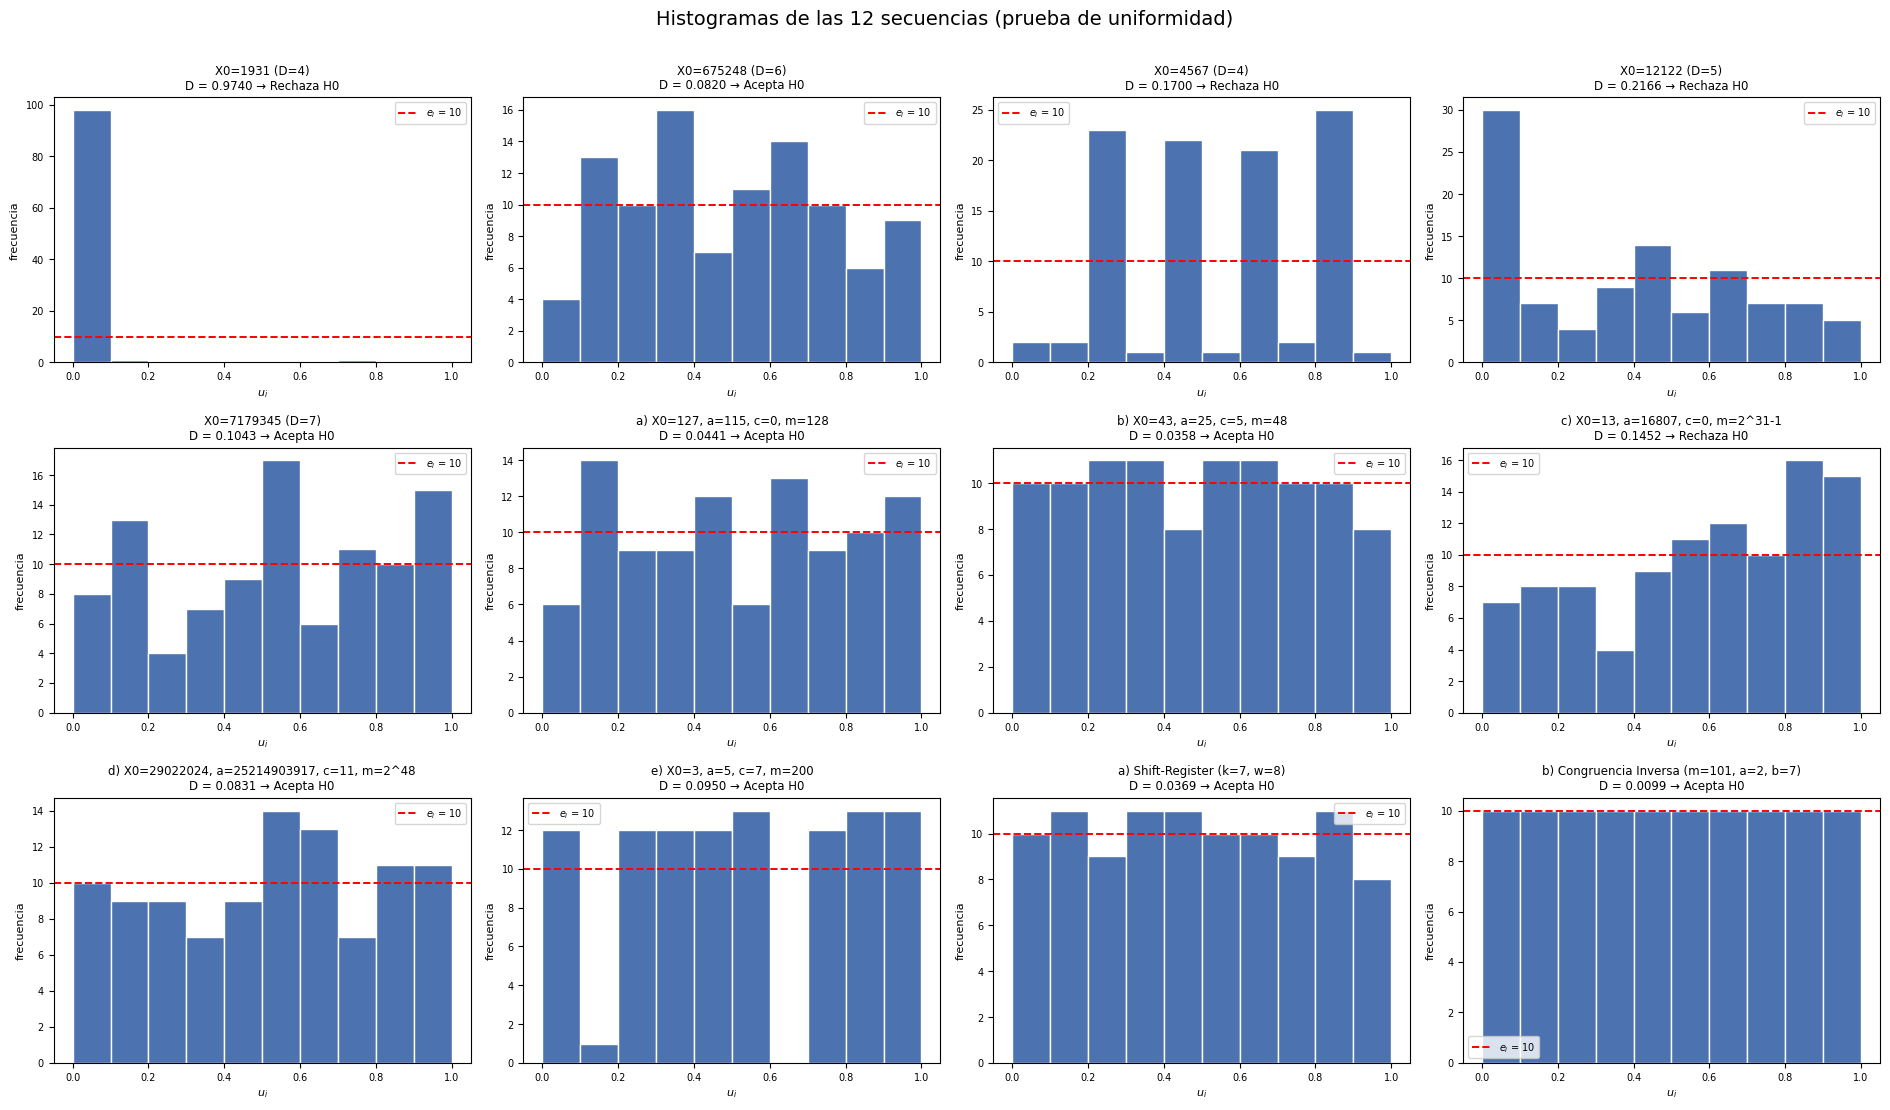

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(19, 11))
for ax, (grupo, etq, U, mu, lam, nota) in zip(axes.ravel(), secuencias):
    ks = ks_uniformidad(U)
    ax.hist(U, bins=10, range=(0, 1), color="#4C72B0", edgecolor="white")
    ax.axhline(N / 10, color="red", ls="--", lw=1.4, label="$e_i$ = 10")
    ax.set_title(f"{etq}\nD = {ks['D']:.4f} → {ks['decision']}", fontsize=8.5)
    ax.set_xlabel("$u_i$", fontsize=8); ax.set_ylabel("frecuencia", fontsize=8)
    ax.tick_params(labelsize=7); ax.legend(fontsize=7)
fig.suptitle("Histogramas de las 12 secuencias (prueba de uniformidad)", fontsize=14, y=1.005)
fig.tight_layout(); plt.show()


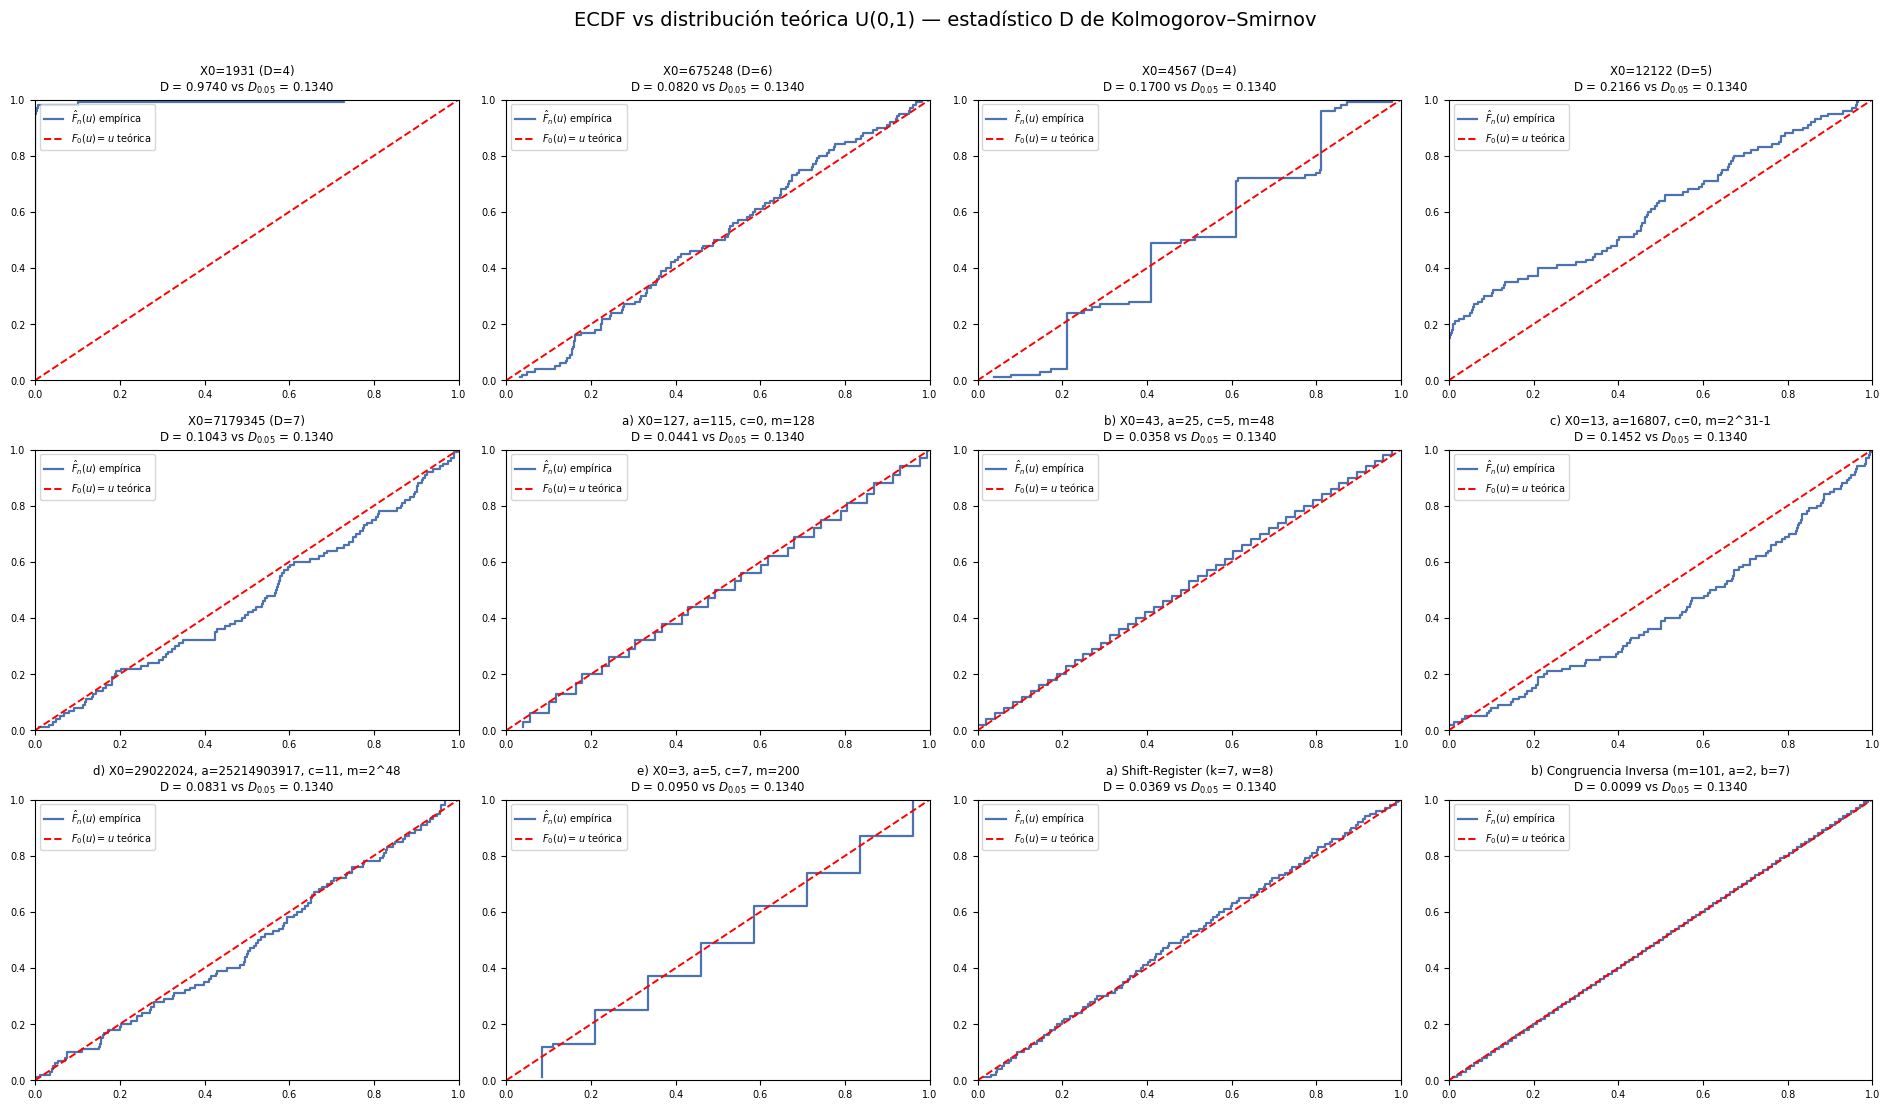

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(19, 11))
for ax, (grupo, etq, U, mu, lam, nota) in zip(axes.ravel(), secuencias):
    ks = ks_uniformidad(U)
    u = np.sort(np.asarray(U, dtype=float))
    ecdf = np.arange(1, len(u) + 1) / len(u)
    ax.step(u, ecdf, where="post", color="#4C72B0", lw=1.6, label="$\\hat F_n(u)$ empírica")
    ax.plot([0, 1], [0, 1], color="red", ls="--", lw=1.4, label="$F_0(u)=u$ teórica")
    ax.set_title(f"{etq}\nD = {ks['D']:.4f} vs $D_{{0.05}}$ = {ks['D_alpha']:.4f}", fontsize=8.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.tick_params(labelsize=7); ax.legend(fontsize=7, loc="upper left")
fig.suptitle("ECDF vs distribución teórica U(0,1) — estadístico D de Kolmogorov–Smirnov",
             fontsize=14, y=1.005)
fig.tight_layout(); plt.show()


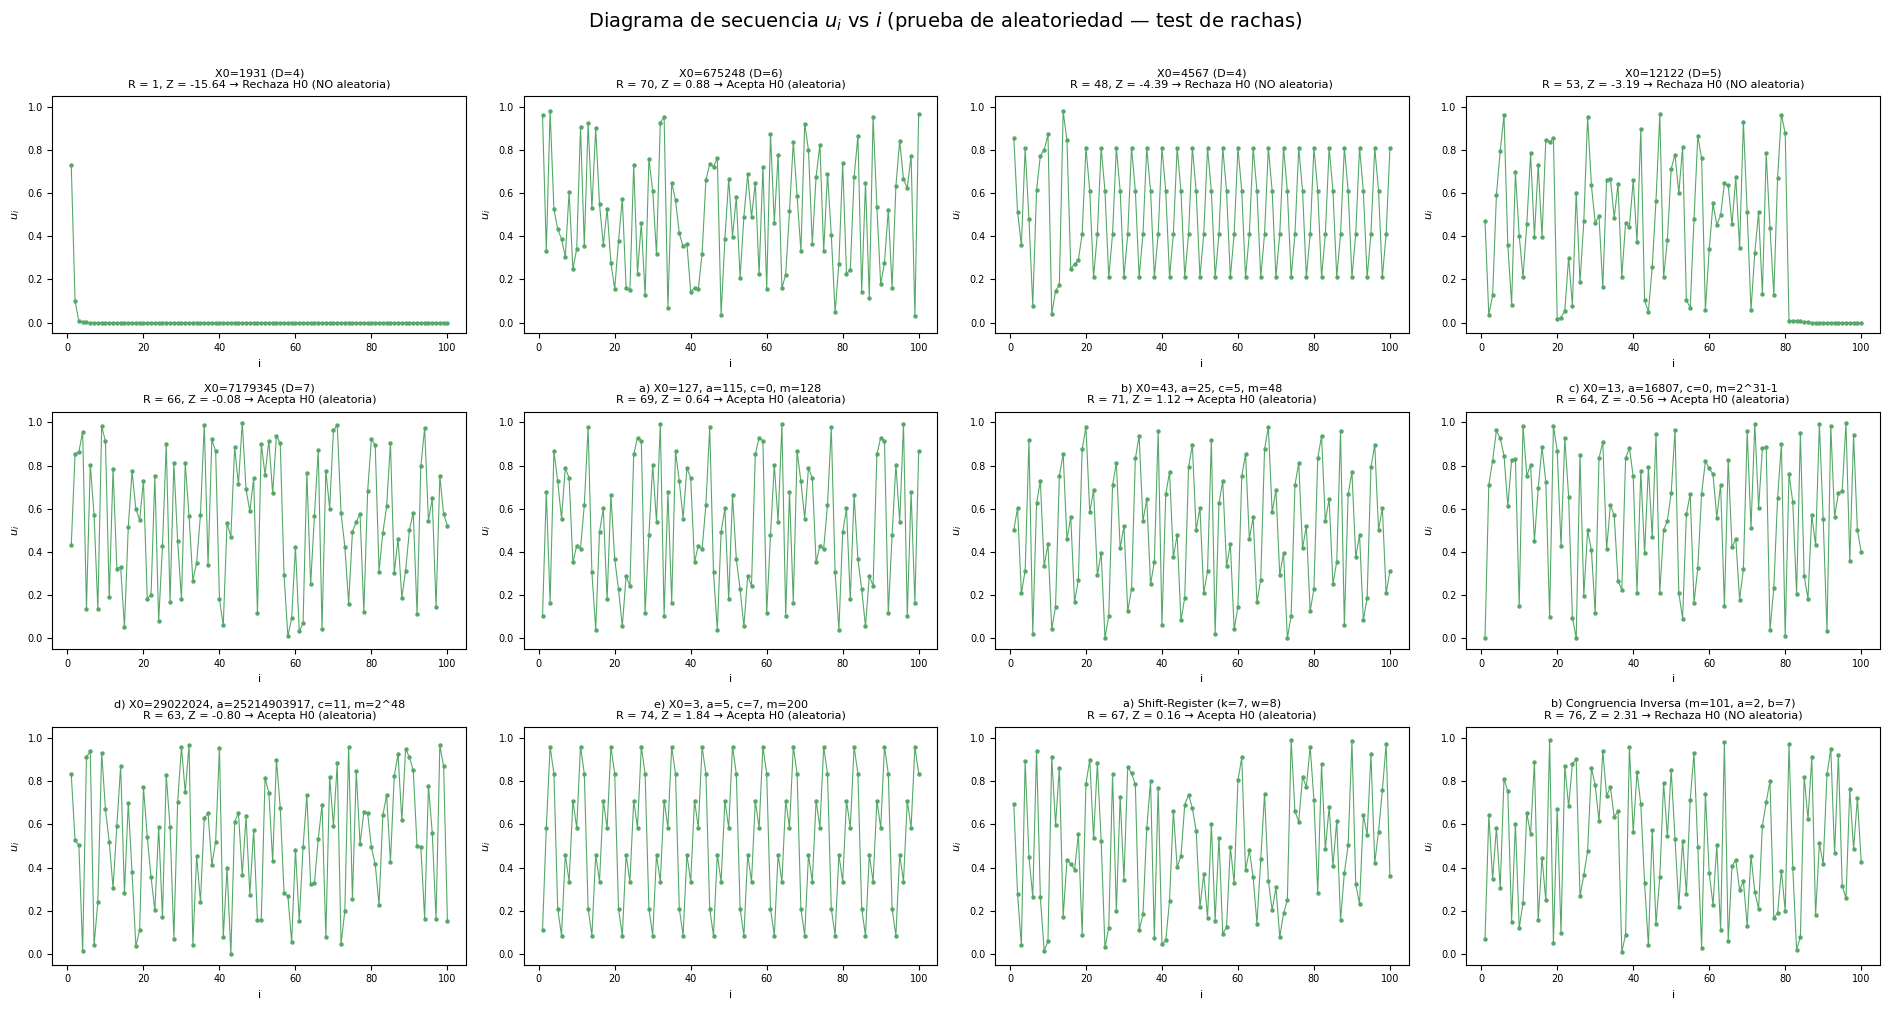

In [19]:
# Diagrama de secuencia: permite ver visualmente tendencia, periodicidad o alternancia
fig, axes = plt.subplots(3, 4, figsize=(19, 10))
for ax, (grupo, etq, U, mu, lam, nota) in zip(axes.ravel(), secuencias):
    ra = test_rachas(U)
    ax.plot(range(1, len(U) + 1), U, marker="o", ms=2.2, lw=0.8, color="#55A868")
    z_txt = "-" if ra["Z"] is None else f"{ra['Z']:.2f}"
    ax.set_title(f"{etq}\nR = {ra['R']}, Z = {z_txt} → {ra['decision']}", fontsize=8)
    ax.set_xlabel("i", fontsize=8); ax.set_ylabel("$u_i$", fontsize=8)
    ax.set_ylim(-0.05, 1.05); ax.tick_params(labelsize=7)
fig.suptitle("Diagrama de secuencia $u_i$ vs $i$ (prueba de aleatoriedad — test de rachas)",
             fontsize=14, y=1.005)
fig.tight_layout(); plt.show()


---

#### Respuestas a las preguntas

De acuerdo con el tamaño de ciclo encontrado y las pruebas de uniformidad y aleatoriedad:

##### Resumen de lo obtenido

| Punto | Generador | Periodo $\lambda$ | Cola $\mu$ | $D$ (KS) | KS | $\chi^2$ | $Z$ (rachas) | Rachas | Pruebas |
|---|---|---|---|---|---|---|---|---|---|
| 5.1.1 | MidSquare $X_0=1931$ | **1** | 7 | 0.9740 | FALLA | FALLA | −15.64 | FALLA | 0/3 |
| 5.1.1 | MidSquare $X_0=675248$ | **1** | 210 | 0.0820 | PASA | PASA | 0.88 | PASA | 3/3 |
| 5.1.1 | MidSquare $X_0=4567$ | **4** | 19 | 0.1700 | FALLA | FALLA | −4.39 | FALLA | 0/3 |
| 5.1.1 | MidSquare $X_0=12122$ | **1** | 88 | 0.2166 | FALLA | FALLA | −3.19 | FALLA | 0/3 |
| 5.1.1 | MidSquare $X_0=7179345$ | **20** | 848 | 0.1043 | PASA | PASA | −0.08 | PASA | 3/3 |
| 5.1.2 | GLC a) $m=128$ | **32** | 0 | 0.0441 | PASA | PASA | 0.64 | PASA | 3/3 |
| 5.1.2 | GLC b) $m=48$ | **48** | 0 | 0.0358 | PASA | PASA | 1.12 | PASA | 3/3 |
| 5.1.2 | GLC c) $m=2^{31}-1$ | **2 147 483 646** | 0 | 0.1452 | FALLA | PASA | −0.56 | PASA | 2/3 |
| 5.1.2 | GLC d) $m=2^{48}$ | **281 474 976 710 656** | 0 | 0.0831 | PASA | PASA | −0.80 | PASA | 3/3 |
| 5.1.2 | GLC e) $m=200$ | **8** | 2 | 0.0950 | PASA | FALLA | 1.84 | PASA | 2/3 |
| 5.1.3 | Shift-Register | **127** | 0 | 0.0369 | PASA | PASA | 0.16 | PASA | 3/3 |
| 5.1.3 | Congruencia Inversa | **101** | 0 | 0.0099 | PASA | PASA | 2.31 | **FALLA** | 2/3 |

Nótese que la congruencia inversa es el generador **más uniforme** de todos y aun así **falla** el test de rachas ($|Z| = 2.31 > 1.96$).

> **Advertencia metodológica importante:** un generador cuyo periodo es **menor o igual** que el tamaño de
> la muestra ($\lambda \le n = 100$) recorre su ciclo completo dentro de la muestra, de modo que "acierta"
> las pruebas de uniformidad de manera **artificial**: al enumerar todos sus estados una o varias veces
> exactas, produce un histograma perfectamente plano. Por eso el criterio del **tamaño de ciclo debe
> analizarse antes que las pruebas estadísticas**, no después.

---

##### ¿Cuáles son los peores generadores de números aleatorios y por qué?

**1. MidSquare con $X_0 = 1931$ — el peor de todos.**
Es el caso más catastrófico. Tras solo 7 iteraciones la secuencia colapsa al estado absorbente
$X_i = 0$ y **el periodo es $\lambda = 1$**: a partir de ahí devuelve $u_i = 0$ indefinidamente
(93 de los 100 valores son exactamente 0). Falla las tres pruebas de forma extrema: $D = 0.9740$ frente a
$D_{0.05} = 0.1340$, $\chi^2 = 860.6$ frente a 16.919, y $Z = -15.64$ con una sola racha. No es un
generador de números aleatorios: es una constante.

**2. MidSquare con $X_0 = 12122$ y $X_0 = 4567$.**
Sufren la misma patología del método de cuadrados medios. El de $X_0 = 12122$ degenera a cero en la
iteración 88 ($\lambda = 1$) y el de $X_0 = 4567$ cae en el ciclo corto
$4100 \to 8100 \to 6100 \to 2100$ de **$\lambda = 4$**, de modo que 82 de los 100 valores son apenas
4 números repetidos. Ambos rechazan las tres pruebas.

**3. Congruencial mixto e) $X_0=3$, $a=5$, $c=7$, $m=200$.**
Su **periodo es de solo $\lambda = 8$**: en 100 números genera únicamente 9 valores distintos. No cumple
las condiciones de Hull–Dobell para periodo completo, porque $m = 200 = 2^3 \cdot 5^2$ es divisible por 5
pero $a - 1 = 4$ no lo es. Aunque los 8 valores del ciclo están repartidos y por eso "pasa" el KS
($D = 0.0950$), el contraste $\chi^2$ lo **rechaza** ($\chi^2 = 22.8 > 16.919$) porque hay clases con
frecuencia 0 y 1 mientras las demás tienen 12 o 13. Es un buen ejemplo de por qué el periodo debe
revisarse siempre: pasar una prueba de uniformidad con periodo 8 no significa nada.

**4. Congruencial mixto a) $m = 128$ y b) $m = 48$ — malos por periodo, no por distribución.**
Pasan las tres pruebas, pero su periodo es $\lambda = 32$ y $\lambda = 48$ respectivamente, es decir,
**menor que la muestra de $n=100$**. Pasan la uniformidad justamente porque recorren su ciclo completo
2 o 3 veces enteras, lo cual produce un histograma plano de forma trivial. El caso a) además usa
$c = 0$ con $m = 2^7$, y al ser multiplicativo con módulo potencia de 2 su periodo máximo posible es
apenas $m/4 = 32$, que es exactamente lo que se obtuvo. Para cualquier simulación real son inservibles:
se repetirían decenas de veces.

**5. Generador de congruencia inversa (con estos parámetros).**
Tiene periodo completo $\lambda = m = 101$ y la mejor uniformidad de todo el laboratorio
($D = 0.0099$, $\chi^2 = 0.00$, con exactamente 10 observaciones en cada una de las 10 clases), pero
**falla el test de rachas** ($R = 76$ frente a los 66.33 esperados, $Z = 2.31 > 1.96$). Ese exceso de
rachas revela un patrón de **alternancia** (zig-zag) entre valores altos y bajos: los números están
perfectamente repartidos pero **no llegan en orden aleatorio**. Es la mejor ilustración del laboratorio
de que uniformidad y aleatoriedad son propiedades distintas e independientes: se puede ser
perfectamente uniforme y aun así no ser aleatorio.

---

##### ¿Cuáles son los mejores generadores de números aleatorios y por qué?

**1. Congruencial mixto d) $X_0 = 29022024$, $a = 25214903917$, $c = 11$, $m = 2^{48}$ — el mejor.**
Es el único que combina las tres virtudes:

- **Periodo máximo posible**: $\lambda = m = 2^{48} \approx 2.8 \times 10^{14}$. Cumple las tres
  condiciones de Hull–Dobell: $\gcd(c, m) = \gcd(11, 2^{48}) = 1$; $a - 1 = 25214903916$ es divisible
  por 2, que es el único factor primo de $m$; y como $4 \mid m$, también $4 \mid (a-1)$.
- **Uniformidad**: pasa ambos contrastes con holgura ($D = 0.0831 < 0.1340$, $p = 0.469$;
  $\chi^2 = 4.80 < 16.919$, $p = 0.851$).
- **Aleatoriedad**: pasa el test de rachas cómodamente ($R = 63$, $Z = -0.80$, $p = 0.425$).

Es el generador que usa `java.util.Random` y `drand48()` de C, precisamente por estas propiedades.

**2. Generador Shift-Register (LFSR con $k = 7$, $w = 8$).**
Alcanza el **periodo máximo de su registro**, $\lambda = 2^7 - 1 = 127$ bits (secuencia de longitud
máxima o *m-sequence*), y pasa las tres pruebas con muy buenos márgenes: $D = 0.0369$ ($p = 0.999$),
$\chi^2 = 1.00$ ($p = 0.999$) y $R = 67$ con $Z = 0.16$ ($p = 0.873$), es decir, prácticamente el número
de rachas esperado. Su única limitación es de escala, no de calidad: con $k = 7$ el periodo es corto
para una simulación grande, pero eso se corrige de inmediato aumentando $k$ (con $k = 31$ o $k = 89$ el
periodo pasa a ser astronómico) sin cambiar el algoritmo. Además es muy eficiente, pues solo usa XOR y
desplazamientos.

**3. Congruencial mixto c) $X_0 = 13$, $a = 16807$, $c = 0$, $m = 2^{31}-1$ (MINSTD / Lehmer).**
Su **periodo es $\lambda = m - 1 = 2\,147\,483\,646$**, el máximo alcanzable por un generador
multiplicativo, porque $m$ es el primo de Mersenne $2^{31}-1$ y $a = 16807 = 7^5$ es raíz primitiva
módulo $m$. Pasa el $\chi^2$ ($\chi^2 = 12.0$, $p = 0.213$) y el test de rachas ($Z = -0.56$,
$p = 0.577$). Solo falla el KS de forma **marginal**: $D = 0.1452$ frente a $D_{0.05} = 0.1340$, con
$p = 0.0264$, un rechazo apenas por debajo del umbral $\alpha = 0.05$ que se explica por la variabilidad
propia de una muestra de apenas $n = 100$ y no por un defecto estructural del generador (con $\alpha=0.01$,
$D_{0.01} = 0.1607$, se aceptaría). Es un generador clásico y ampliamente validado.

**4. MidSquare con $X_0 = 7179345$ y $X_0 = 675248$ — buenos solo por suerte.**
Pasan las tres pruebas dentro de la ventana de $n = 100$ ($D = 0.1043$ y $D = 0.0820$; $Z = -0.08$ y
$Z = 0.88$), pero **no son recomendables**: al seguir la secuencia más allá de los 100 valores se
comprueba que el de $X_0 = 7179345$ cae en un ciclo de $\lambda = 20$ después de 848 iteraciones, y el
de $X_0 = 675248$ **degenera a cero** en la iteración 210 ($\lambda = 1$). Es decir, los buenos
resultados se deben únicamente a que la muestra se cortó antes de que apareciera la patología. Esto
confirma el defecto de fondo del método de cuadrados medios: su comportamiento depende críticamente de
la semilla, no ofrece ninguna garantía teórica sobre el periodo, y siempre termina degenerando.

---

##### Conclusión general

**Ranking final:** GLC $m=2^{48}$ > Shift-Register > GLC $m=2^{31}-1$ > Congruencia inversa >
GLC $m=48$ > GLC $m=128$ > MidSquare (7179345, 675248) > GLC $m=200$ > MidSquare (4567, 12122, 1931).

Las conclusiones del laboratorio son tres:

1. **El tamaño de ciclo es el criterio previo y decisivo.** Un generador con periodo pequeño puede pasar
   las pruebas estadísticas de forma engañosa (casos $m=128$, $m=48$), porque recorrer el ciclo completo
   produce un histograma perfectamente plano. Un buen generador debe tener un periodo mucho mayor que la
   cantidad de números que se van a consumir en la simulación.

2. **Uniformidad y aleatoriedad son propiedades independientes y hay que probar ambas.** El generador de
   congruencia inversa es el más uniforme de todos ($\chi^2 = 0.00$) y aun así no es aleatorio
   ($Z = 2.31$): sus valores están perfectamente repartidos pero llegan alternando alto-bajo. Una sola
   prueba nunca es suficiente.

3. **El método de cuadrados medios (MidSquare) debe descartarse en la práctica.** De sus cinco semillas,
   tres fallaron las tres pruebas y las dos que las pasaron degeneran igualmente si se extiende la
   secuencia. No tiene garantía teórica de periodo y siempre acaba en ciclos cortos o en el estado
   absorbente cero. Los generadores congruenciales lineales con parámetros que cumplen Hull–Dobell (o
   raíz primitiva en el caso multiplicativo) y los de registro de desplazamiento son las opciones
   correctas.


---

## 5.2 Uso de números aleatorios para evaluar integrales

La idea de la sección 3.2 de [Ross99] es que si $U \sim U(0,1)$, entonces

$$\theta = \int_0^1 g(x)\,dx = E[g(U)],$$

así que basta con generar $u_1, \dots, u_k$ y promediar $g(u_i)$. Por la ley fuerte de los grandes
números ese promedio converge a $\theta$ con probabilidad 1.

Cuando la integral no está entre 0 y 1 hay que llevarla a ese intervalo con un cambio de variable.
El libro da los dos que se necesitan aquí:

| Caso | Sustitución | Función que se promedia |
|---|---|---|
| $\int_a^b g(x)\,dx$ | $y = \dfrac{x-a}{b-a}$ | $h(y) = (b-a)\,g\big(a + (b-a)y\big)$ |
| $\int_0^{\infty} g(x)\,dx$ | $y = \dfrac{1}{x+1}$ | $h(y) = \dfrac{g\!\left(\frac{1}{y}-1\right)}{y^2}$ |

Como fuente de los $u_i$ uso el generador congruencial mixto del literal d) del punto 5.1.2
($X_0 = 29022024$, $a = 25214903917$, $c = 11$, $m = 2^{48}$), que fue el que quedó mejor calificado
en el punto 5.1.4: periodo $2^{48}$ y las tres pruebas superadas. Usar aquí un generador con periodo
corto sería un error, porque solo en este punto se consumen casi un millón de números.


In [20]:
# ---------------------------------------------------------------------------
# Fuente de numeros aleatorios de todo el punto 5.2.
# Se usa el generador congruencial mixto d) del punto 5.1.2, que fue el mejor
# calificado en 5.1.4: periodo 2^48 y las tres pruebas superadas.
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, stats


class GLC:
    # Generador congruencial mixto:  X_{n+1} = (a*X_n + c) mod m
    def __init__(self, x0, a=25214903917, c=11, m=2**48):
        self.a, self.c, self.m, self.x0 = a, c, m, x0
        self.x = x0
        self.consumidos = 0

    def rand(self):
        self.x = (self.a * self.x + self.c) % self.m
        self.consumidos += 1
        return self.x / self.m

    def rands(self, n):
        out = np.empty(n, dtype=float)
        x, a, c, m = self.x, self.a, self.c, self.m
        for i in range(n):
            x = (a * x + c) % m
            out[i] = x / m
        self.x = x
        self.consumidos += n
        return out

    def reset(self, x0=None):
        self.x = self.x0 if x0 is None else x0
        self.consumidos = 0
        return self


X0_52 = 29022024                 # semilla d) del punto 5.1.2
gen52 = GLC(X0_52)

print("Generador del punto 5.2:  X0 = %d,  a = %d,  c = %d,  m = 2^48" % (X0_52, 25214903917, 11))
print("Primeros 5 numeros:", np.round(gen52.rands(5), 6))
gen52.reset()


Generador del punto 5.2:  X0 = 29022024,  a = 25214903917,  c = 11,  m = 2^48
Primeros 5 numeros: [0.831627 0.526397 0.503802 0.012274 0.911276]


### Reescritura de cada integral sobre $(0,1)$

| Ej. | Integral | Cambio de variable | Función que se promedia |
|---|---|---|---|
| 3 | $\int_0^1 \exp\{e^x\}\,dx$ | ninguno | $h(u) = e^{e^u}$ |
| 4 | $\int_0^1 (1-x^2)^{3/2}\,dx$ | ninguno | $h(u) = (1-u^2)^{3/2}$ |
| 5 | $\int_{-2}^{2} e^{x+x^2}\,dx$ | $x = -2 + 4u$ | $h(u) = 4\,e^{x+x^2}$ |
| 6 | $\int_0^{\infty} x(1+x^2)^{-2}\,dx$ | $x = \frac1u - 1$ | $h(u) = \dfrac{x(1+x^2)^{-2}}{u^2}$ |
| 7 | $\int_{-\infty}^{\infty} e^{-x^2}\,dx$ | simetría y $x = \frac1u - 1$ | $h(u) = \dfrac{2e^{-x^2}}{u^2}$ |
| 8 | $\int_0^1\!\!\int_0^1 e^{(x+y)^2}\,dy\,dx$ | ninguno | $h(u,v) = e^{(u+v)^2}$ |
| 9 | $\int_0^{\infty}\!\!\int_0^{x} e^{-(x+y)}\,dy\,dx$ | $I_y(x)$, $x = \frac1u-1$, $y=\frac1v-1$ | $h(u,v) = \dfrac{e^{-(x+y)}\,I_y(x)}{u^2v^2}$ |

Tres observaciones sobre esos cambios:

* En el ejercicio 7 el integrando es par, así que
  $\int_{-\infty}^{\infty} e^{-x^2}dx = 2\int_0^{\infty} e^{-x^2}dx$ y ya se puede aplicar la
  sustitución del libro. Es más limpio que partir la recta en dos mitades.
* En el ejercicio 9 la sugerencia de la guía es clave. Definiendo $I_y(x) = 1$ si $y < x$ y 0 en
  caso contrario, el límite superior variable desaparece:
  $\int_0^{\infty}\int_0^{x} e^{-(x+y)}dy\,dx = \int_0^{\infty}\int_0^{\infty} e^{-(x+y)} I_y(x)\,dy\,dx$,
  y ahora las dos variables van de 0 a $\infty$, así que se les aplica la misma sustitución a las dos.
* Los ejercicios 6, 7 y 9 dividen por $u^2$, de modo que un $u_i$ muy cercano a cero da un valor
  enorme. El generador con $m = 2^{48}$ nunca devuelve 0 exacto, así que no hay división por cero,
  pero hay que tenerlo presente porque es la razón de que esos estimadores tengan más varianza.

Como referencia para comparar uso el valor exacto donde se conoce ($3\pi/16$ en el 4, $1/2$ en el 6 y
en el 9, $\sqrt{\pi}$ en el 7) y cuadratura numérica de `scipy` en los tres restantes.


In [21]:
# ---------------------------------------------------------------------------
# Cada integral se reescribe sobre (0,1) con las sustituciones de la seccion 3.2
# de [Ross99] y luego se estima como el promedio de h evaluada en los u_i.
#
#   limites finitos [a,b]  ->  x = a + (b-a)y ,  h(y) = (b-a)*g(a + (b-a)y)
#   limite infinito [0,oo) ->  x = 1/y - 1    ,  h(y) = g(1/y - 1) / y^2
# ---------------------------------------------------------------------------

def h3(u):                                  # int_0^1 exp(e^x) dx
    return np.exp(np.exp(u))

def h4(u):                                  # int_0^1 (1 - x^2)^(3/2) dx
    return (1.0 - u**2)**1.5

def h5(u):                                  # int_{-2}^{2} e^(x + x^2) dx ; x = -2 + 4u
    x = -2.0 + 4.0*u
    return 4.0*np.exp(x + x*x)

def h6(u):                                  # int_0^oo x (1 + x^2)^(-2) dx ; x = 1/u - 1
    x = 1.0/u - 1.0
    return x*(1.0 + x*x)**-2 / (u*u)

def h7(u):                                  # int_-oo^oo e^(-x^2) dx = 2 * int_0^oo e^(-x^2) dx
    x = 1.0/u - 1.0
    return 2.0*np.exp(-x*x) / (u*u)

def h8(u, v):                               # int_0^1 int_0^1 e^((x+y)^2) dy dx
    return np.exp((u + v)**2)

def h9(u, v):                               # int_0^oo int_0^x e^(-(x+y)) dy dx
    x = 1.0/u - 1.0                         # sugerencia de la guia: I_y(x) = 1 si y < x
    y = 1.0/v - 1.0
    return np.exp(-(x + y)) * (y < x) / (u*u * v*v)


INTEGRALES = {
    3: dict(h=h3, dim=1, enunciado=r"$\int_0^1 \exp\{e^x\}\,dx$",
            cambio="ninguno, ya esta en (0,1)"),
    4: dict(h=h4, dim=1, enunciado=r"$\int_0^1 (1-x^2)^{3/2}\,dx$",
            cambio="ninguno, ya esta en (0,1)"),
    5: dict(h=h5, dim=1, enunciado=r"$\int_{-2}^{2} e^{x+x^2}\,dx$",
            cambio="x = -2 + 4y"),
    6: dict(h=h6, dim=1, enunciado=r"$\int_0^{\infty} x(1+x^2)^{-2}\,dx$",
            cambio="x = 1/y - 1"),
    7: dict(h=h7, dim=1, enunciado=r"$\int_{-\infty}^{\infty} e^{-x^2}\,dx$",
            cambio="simetria + x = 1/y - 1"),
    8: dict(h=h8, dim=2, enunciado=r"$\int_0^1\!\!\int_0^1 e^{(x+y)^2}\,dy\,dx$",
            cambio="ninguno, ya esta en (0,1)^2"),
    9: dict(h=h9, dim=2, enunciado=r"$\int_0^{\infty}\!\!\int_0^{x} e^{-(x+y)}\,dy\,dx$",
            cambio="I_y(x) + x = 1/u - 1, y = 1/v - 1"),
}

# Valor exacto o de referencia (cuadratura numerica de scipy) para poder comparar
EXACTOS = {
    3: integrate.quad(lambda x: np.exp(np.exp(x)), 0, 1)[0],
    4: 3*np.pi/16,
    5: integrate.quad(lambda x: np.exp(x + x*x), -2, 2)[0],
    6: 0.5,
    7: np.sqrt(np.pi),
    8: integrate.dblquad(lambda y, x: np.exp((x + y)**2), 0, 1, 0, 1)[0],
    9: 0.5,
}
FUENTE_EXACTO = {3: "cuadratura", 4: "3*pi/16", 5: "cuadratura", 6: "1/2",
                 7: "raiz(pi)", 8: "cuadratura", 9: "1/2"}

for k in sorted(EXACTOS):
    print("Ejercicio %d  ->  valor de referencia = %.6f   (%s)" % (k, EXACTOS[k], FUENTE_EXACTO[k]))


Ejercicio 3  ->  valor de referencia = 6.316564   (cuadratura)
Ejercicio 4  ->  valor de referencia = 0.589049   (3*pi/16)
Ejercicio 5  ->  valor de referencia = 93.162753   (cuadratura)
Ejercicio 6  ->  valor de referencia = 0.500000   (1/2)
Ejercicio 7  ->  valor de referencia = 1.772454   (raiz(pi))
Ejercicio 8  ->  valor de referencia = 4.899159   (cuadratura)
Ejercicio 9  ->  valor de referencia = 0.500000   (1/2)


#### Estimación con $k = 100$, $1\,000$, $10\,000$ y $100\,000$ números aleatorios


In [22]:
# --------- Estimacion Monte Carlo con k = 100, 1000, 10 000 y 100 000 ---------
TAMANOS = [100, 1_000, 10_000, 100_000]

gen52.reset()
filas = []
for ej in sorted(INTEGRALES):
    info = INTEGRALES[ej]
    for k in TAMANOS:
        if info["dim"] == 1:
            u = gen52.rands(k)
            est = float(np.mean(info["h"](u)))
        else:
            u = gen52.rands(k)
            v = gen52.rands(k)
            est = float(np.mean(info["h"](u, v)))
        exacto = EXACTOS[ej]
        filas.append({"Ej.": ej, "k": k, "Estimacion": round(est, 6),
                      "Valor exacto": round(exacto, 6),
                      "Error abs.": round(abs(est - exacto), 6),
                      "Error rel. %": round(100*abs(est - exacto)/abs(exacto), 4)})

tabla52 = pd.DataFrame(filas)
print("Numeros aleatorios consumidos en total:", gen52.consumidos)
display(tabla52)


Numeros aleatorios consumidos en total: 999900


,Ej.,k,Estimacion,Valor exacto,Error abs.,Error rel. %
0,3,100,6.464899,6.316564,0.148335,2.3483
1,3,1000,6.277994,6.316564,0.038570,0.6106
2,3,10000,6.311353,6.316564,0.005211,0.0825
3,3,100000,6.313964,6.316564,0.002600,0.0412
4,4,100,0.596737,0.589049,0.007688,1.3052
5,4,1000,0.586579,0.589049,0.002470,0.4193
6,4,10000,0.588960,0.589049,0.000089,0.0151
7,4,100000,0.590144,0.589049,0.001095,0.1859
8,5,100,29.225252,93.162753,63.937502,68.6299
9,5,1000,87.754938,93.162753,5.407815,5.8047


#### Convergencia de las estimaciones


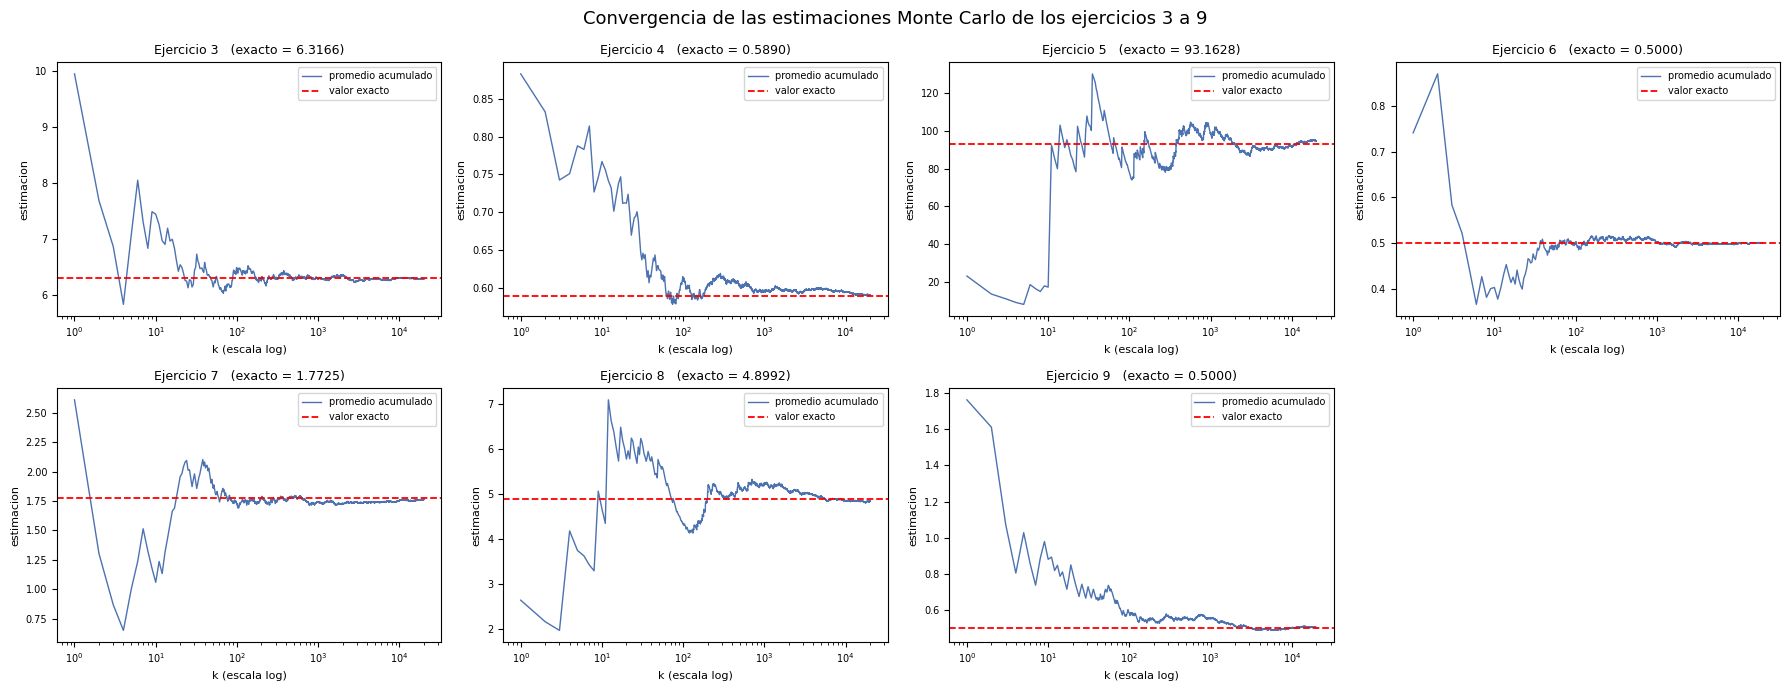

In [23]:
# --------- Convergencia: promedio acumulado frente al valor exacto ---------
gen52.reset()
K = 20_000
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, ej in zip(axes.ravel(), sorted(INTEGRALES)):
    info = INTEGRALES[ej]
    if info["dim"] == 1:
        vals = info["h"](gen52.rands(K))
    else:
        vals = info["h"](gen52.rands(K), gen52.rands(K))
    corrida = np.cumsum(vals) / np.arange(1, K + 1)
    ax.plot(np.arange(1, K + 1), corrida, lw=1.0, color="#4C72B0", label="promedio acumulado")
    ax.axhline(EXACTOS[ej], color="red", ls="--", lw=1.3, label="valor exacto")
    ax.set_xscale("log")
    ax.set_title("Ejercicio %d   (exacto = %.4f)" % (ej, EXACTOS[ej]), fontsize=9)
    ax.set_xlabel("k (escala log)", fontsize=8)
    ax.set_ylabel("estimacion", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
axes.ravel()[-1].axis("off")
fig.suptitle("Convergencia de las estimaciones Monte Carlo de los ejercicios 3 a 9", fontsize=13)
fig.tight_layout()
plt.show()


### Análisis de los resultados del punto 5.2

Con $k = 100\,000$ los siete estimadores quedan por debajo del 0.5 % de error relativo, y el
promedio de los siete es 0.17 %. El comportamiento con muestras chicas es otra historia y ahí está
lo interesante:

* El ejercicio 5 es el caso extremo. Con $k = 100$ la estimación fue 29.23 frente al valor real
  93.16, un error del 68.6 %. La explicación está en el integrando: sobre $[-2,2]$, la función
  $e^{x+x^2}$ vale 0.78 en su mínimo y 403.4 en $x = 2$, así que un puñado de puntos cerca del
  extremo derecho decide casi todo el promedio. Si en 100 sorteos ninguno cae ahí, la estimación se
  queda corta. Con $k = 1\,000$ el error ya baja a 5.8 % y con $k = 100\,000$ a 0.49 %.
* Los ejercicios 8 y 9 arrancan con 16.1 % y 12.5 % de error con $k=100$. En el 9 la razón es
  distinta a la del 5: el indicador $I_y(x)$ anula aproximadamente la mitad de las evaluaciones, así
  que de 100 pares solo unos 50 aportan información.
* El ejercicio 4 es el que mejor se porta desde el comienzo, con 1.31 % de error con apenas 100
  números. Su integrando es suave y está acotado entre 0 y 1, así que la varianza de $h(U)$ es
  pequeña.

El patrón general se ve en las gráficas de convergencia: el error cae aproximadamente como
$1/\sqrt{k}$. Multiplicar la muestra por 100 reduce el error alrededor de 10 veces, no 100. Entre
$k=100$ y $k=10\,000$ el error del ejercicio 3 pasó de 2.35 % a 0.083 %, y el del 7 de 8.24 % a
0.43 %. Esa lentitud es el precio del método Monte Carlo, y por eso importa tanto que el generador de
la base tenga un periodo grande: acá se consumieron 999 900 números solo para llenar la tabla, mucho
más que el periodo de siete de los doce generadores evaluados en 5.1.4.


---

## 5.3 Generación de variables aleatorias discretas

El método de la transformada inversa discreta de la sección 4.1 de [Ross99] parte la unidad en
subintervalos cuyas longitudes son las probabilidades $p_j$, y devuelve el valor $j$ cuyo
subintervalo contiene al número aleatorio:

$$X = j \quad \text{si} \quad F(j-1) \le U < F(j), \qquad F(j) = \sum_{i \le j} p_i.$$

Todo este punto usa el generador congruencial mixto que exige la guía:
$X_0 = 2391$, $a = 25214903917$, $c = 11$, $m = 2^{48}$. Cada literal vuelve a arrancar en
$X_0 = 2391$, así que los cuatro parten de la misma sucesión $u_1, \dots, u_{100}$ y lo único que
cambia entre uno y otro es cómo se parte el intervalo $(0,1)$.


In [24]:
# ---------------------------------------------------------------------------
# Generador exigido por la guia para todo el punto 5.3:
#     X0 = 2391,  a = 25214903917,  c = 11,  m = 2^48
# Cada literal vuelve a arrancar en X0 = 2391, asi que todos parten de la
# MISMA sucesion u_1, ..., u_100 y lo unico que cambia es la particion de (0,1).
# ---------------------------------------------------------------------------
X0_53 = 2391
gen53 = GLC(X0_53)

u100 = gen53.rands(100)
print("Primeros 10 numeros u_i del generador (X0 = 2391):")
print(np.round(u100[:10], 6))
print("min = %.6f   max = %.6f   media = %.6f" % (u100.min(), u100.max(), u100.mean()))


def transformada_inversa(u, p):
    # Metodo de la transformada inversa discreta (seccion 4.1 de [Ross99]).
    # Recorre las clases en el orden dado y devuelve (indice, comparaciones).
    acum = 0.0
    for k, pk in enumerate(p):
        acum += pk
        if u < acum:
            return k, k + 1
    return len(p) - 1, len(p)


def genera_muestra(u, p, valores=None, orden=None):
    # orden = lista de indices en el orden en que se revisan las clases
    if valores is None:
        valores = list(range(1, len(p) + 1))
    if orden is None:
        orden = list(range(len(p)))
    p_ord = [p[i] for i in orden]
    val_ord = [valores[i] for i in orden]
    x, comp = [], []
    for ui in u:
        k, c = transformada_inversa(ui, p_ord)
        x.append(val_ord[k])
        comp.append(c)
    return np.array(x), np.array(comp)


def tabla_frecuencias(x, p, valores=None, titulo=""):
    if valores is None:
        valores = list(range(1, len(p) + 1))
    n = len(x)
    obs = np.array([np.sum(x == v) for v in valores], dtype=float)
    esp = n*np.asarray(p, dtype=float)
    chi2 = float(np.sum((obs - esp)**2 / esp))
    gl = len(p) - 1
    crit = float(stats.chi2.ppf(0.95, gl))
    df = pd.DataFrame({"X = j": valores,
                       "p_j teorica": np.round(p, 4),
                       "Frec. observada": obs.astype(int),
                       "Frec. esperada": np.round(esp, 2),
                       "Frec. relativa": np.round(obs/n, 4)})
    if titulo:
        print(titulo)
    display(df)
    print("Chi-cuadrado = %.4f   gl = %d   critico(0.95) = %.4f   ->  %s"
          % (chi2, gl, crit, "se acepta el ajuste" if chi2 <= crit else "se rechaza el ajuste"))
    return chi2, crit


def mostrar_en_bloques(u, x, ncols=4, titulo=""):
    # Muestra los 100 valores repartidos en varias columnas para que quepan
    n = len(x)
    filas = n // ncols
    d = {}
    for b in range(ncols):
        ini = b*filas
        d[("bloque %d" % (b + 1), "i")] = np.arange(ini + 1, ini + filas + 1)
        if u is not None:
            d[("bloque %d" % (b + 1), "u_i")] = np.round(u[ini:ini + filas], 4)
        d[("bloque %d" % (b + 1), "X_i")] = x[ini:ini + filas]
    if titulo:
        print(titulo)
    display(pd.DataFrame(d))


Primeros 10 numeros u_i del generador (X0 = 2391):
[0.214189 0.744953 0.66098  0.759499 0.783467 0.392438 0.660726 0.898448
 0.35315  0.725281]
min = 0.014151   max = 0.996603   media = 0.489194


### a) $p_1 = 0.20$, $p_2 = 0.15$, $p_3 = 0.25$, $p_4 = 0.40$

Los puntos de corte son $F = (0.20,\ 0.35,\ 0.60,\ 1.00)$. Este caso es literalmente el Ejemplo 4a
del capítulo 4 de [Ross99], donde el libro también muestra una versión más eficiente que revisa las
clases de mayor a menor probabilidad: primero si $u < 0.40$ para $X=4$, luego $u<0.65$ para $X=3$,
luego $u<0.85$ para $X=1$ y si no $X=2$. Se implementan las dos para poder medir la diferencia.


In [25]:
# --------- a)  p1 = 0.20, p2 = 0.15, p3 = 0.25, p4 = 0.40 ---------
p_a = [0.20, 0.15, 0.25, 0.40]

gen53.reset(X0_53)
u_a = gen53.rands(100)

# Version directa: se revisan las clases en el orden natural 1, 2, 3, 4
x_a, comp_a = genera_muestra(u_a, p_a)

# Version eficiente (Ejemplo 4a de [Ross99]): de mayor a menor probabilidad
orden_a = [int(i) for i in np.argsort(p_a)[::-1]]
x_a_ef, comp_a_ef = genera_muestra(u_a, p_a, orden=orden_a)

print("Puntos de corte F(j):", np.round(np.cumsum(p_a), 2))
print("Orden eficiente de revision (valores de X):", [i + 1 for i in orden_a])
print("Comparaciones promedio  ->  orden natural: %.4f   orden eficiente: %.4f  (ahorro %.1f%%)"
      % (comp_a.mean(), comp_a_ef.mean(), 100*(1 - comp_a_ef.mean()/comp_a.mean())))
print("Las dos versiones NO devuelven los mismos 100 valores, porque a cada u_i le")
print("corresponde otro subintervalo. Lo que si coincide es la distribucion:")
print("  frecuencias con orden natural  :", [int(np.sum(x_a == v)) for v in [1, 2, 3, 4]])
print("  frecuencias con orden eficiente:", [int(np.sum(x_a_ef == v)) for v in [1, 2, 3, 4]])
print("  frecuencias esperadas          :", [int(100*p) for p in p_a])
mostrar_en_bloques(u_a, x_a, titulo="Los 100 valores generados en el literal a)")
tabla_frecuencias(x_a, p_a, titulo="Ajuste de las frecuencias del literal a)")


Puntos de corte F(j): [0.2  0.35 0.6  1.  ]
Orden eficiente de revision (valores de X): [4, 3, 1, 2]
Comparaciones promedio  ->  orden natural: 2.8200   orden eficiente: 2.1100  (ahorro 25.2%)
Las dos versiones NO devuelven los mismos 100 valores, porque a cada u_i le
corresponde otro subintervalo. Lo que si coincide es la distribucion:
  frecuencias con orden natural  : [21, 14, 27, 38]
  frecuencias con orden eficiente: [18, 17, 24, 41]
  frecuencias esperadas          : [20, 15, 25, 40]
Los 100 valores generados en el literal a)


bloque 1             bloque 2             bloque 3             bloque 4            
          i     u_i X_i        i     u_i X_i        i     u_i X_i        i     u_i X_i
0         1  0.2142   2       26  0.9761   4       51  0.9122   4       76  0.5728   3
1         2  0.7450   4       27  0.4463   3       52  0.3833   3       77  0.2767   2
2         3  0.6610   4       28  0.9551   4       53  0.4023   3       78  0.0431   1
3         4  0.7595   4       29  0.0542   1       54  0.4465   3       79  0.7684   4
4         5  0.7835   4       30  0.5021   3       55  0.8047   4       80  0.6458   4
5         6  0.3924   3       31  0.7217   4       56  0.8593   4       81  0.2173   2
6         7  0.6607   4       32  0.3320   2       57  0.9462   4       82  0.0465   1
7         8  0.8984   4       33  0.9277   4       58  0.2192   2       83  0.3756   3
8         9  0.3532   3       34  0.2927   2       59  0.8250   4       84  0.0497   1
9        10  0.7253   4       35  0.0441   1       60  0.2329   2       85  0.8645   4
10       11  0.3322   2       36  0.6875   4       61  0.1703   1       86  0.4502   3
11       12  0.0269   1       37  0.9525   4       62  0.7247   4       87  0.4596   3
12       13  0.7009   4       38  0.1507   1       63  0.5738   3       88  0.5001   3
13       14  0.7854   4       39  0.6690   4       64  0.4051   3       89  0.9590   4
14       15  0.0941   1       40  0.6477   4       65  0.4270   3       90  0.5880   3
15       16  0.1854   1       41  0.9503   4       66  0.4484   3       91  0.5592   3
16       17  0.1494   1       42  0.1028   1       67  0.6557   4       92  0.0696   1
17       18  0.1250   1       43  0.2985   2       68  0.1919   1       93  0.1810   1
18       19  0.2157   2       44  0.1437   1       69  0.8793   4       94  0.5129   3
19       20  0.4328   3       45  0.8655   4       70  0.8865   4       95  0.2276   2
20       21  0.6471   4       46  0.4725   3       71  0.0999   1       96  0.6922   4
21       22  0.4762   3       47  0.3369   2       72  0.3652   3       97  0.4788   3
22       23  0.1977   1       48  0.4562   3       73  0.0275   1       98  0.8963   4
23       24  0.3646   3       49  0.7999   4       74  0.8616   4       99  0.0142   1
24       25  0.2446   2       50  0.2578   2       75  0.9966   4      100  0.5108   3

Ajuste de las frecuencias del literal a)


,X = j,p_j teorica,Frec. observada,Frec. esperada,Frec. relativa
0,1,0.20,21,20.0,0.21
1,2,0.15,14,15.0,0.14
2,3,0.25,27,25.0,0.27
3,4,0.40,38,40.0,0.38


Chi-cuadrado = 0.3767   gl = 3   critico(0.95) = 7.8147   ->  se acepta el ajuste


(0.3766666666666667, 7.814727903251179)

### b) $P\{X=1\}=0.3$, $P\{X=2\}=0.2$, $P\{X=3\}=0.35$, $P\{X=4\}=0.15$

Ahora los cortes son $F = (0.30,\ 0.50,\ 0.85,\ 1.00)$. El orden eficiente empieza por $X=3$, que es
el valor más probable con 0.35, y termina en $X=4$ con 0.15.


In [26]:
# --------- b)  P{X=1}=0.3, P{X=2}=0.2, P{X=3}=0.35, P{X=4}=0.15 ---------
p_b = [0.30, 0.20, 0.35, 0.15]

gen53.reset(X0_53)
u_b = gen53.rands(100)

x_b, comp_b = genera_muestra(u_b, p_b)
orden_b = [int(i) for i in np.argsort(p_b)[::-1]]
x_b_ef, comp_b_ef = genera_muestra(u_b, p_b, orden=orden_b)

print("Puntos de corte F(j):", np.round(np.cumsum(p_b), 2))
print("Orden eficiente de revision (valores de X):", [i + 1 for i in orden_b])
print("Frecuencias con orden natural  :", [int(np.sum(x_b == v)) for v in [1, 2, 3, 4]])
print("Frecuencias con orden eficiente:", [int(np.sum(x_b_ef == v)) for v in [1, 2, 3, 4]])
print("Comparaciones promedio  ->  orden natural: %.4f   orden eficiente: %.4f  (ahorro %.1f%%)"
      % (comp_b.mean(), comp_b_ef.mean(), 100*(1 - comp_b_ef.mean()/comp_b.mean())))
print("Valores que cambian respecto al literal a) usando los mismos u_i:",
      int(np.sum(x_a != x_b)), "de 100")
mostrar_en_bloques(u_b, x_b, titulo="Los 100 valores generados en el literal b)")
tabla_frecuencias(x_b, p_b, titulo="Ajuste de las frecuencias del literal b)")


Puntos de corte F(j): [0.3  0.5  0.85 1.  ]
Orden eficiente de revision (valores de X): [3, 1, 2, 4]
Frecuencias con orden natural  : [32, 22, 29, 17]
Frecuencias con orden eficiente: [30, 18, 35, 17]
Comparaciones promedio  ->  orden natural: 2.3100   orden eficiente: 2.1700  (ahorro 6.1%)
Valores que cambian respecto al literal a) usando los mismos u_i: 51 de 100
Los 100 valores generados en el literal b)


bloque 1             bloque 2             bloque 3             bloque 4            
          i     u_i X_i        i     u_i X_i        i     u_i X_i        i     u_i X_i
0         1  0.2142   1       26  0.9761   4       51  0.9122   4       76  0.5728   3
1         2  0.7450   3       27  0.4463   2       52  0.3833   2       77  0.2767   1
2         3  0.6610   3       28  0.9551   4       53  0.4023   2       78  0.0431   1
3         4  0.7595   3       29  0.0542   1       54  0.4465   2       79  0.7684   3
4         5  0.7835   3       30  0.5021   3       55  0.8047   3       80  0.6458   3
5         6  0.3924   2       31  0.7217   3       56  0.8593   4       81  0.2173   1
6         7  0.6607   3       32  0.3320   2       57  0.9462   4       82  0.0465   1
7         8  0.8984   4       33  0.9277   4       58  0.2192   1       83  0.3756   2
8         9  0.3532   2       34  0.2927   1       59  0.8250   3       84  0.0497   1
9        10  0.7253   3       35  0.0441   1       60  0.2329   1       85  0.8645   4
10       11  0.3322   2       36  0.6875   3       61  0.1703   1       86  0.4502   2
11       12  0.0269   1       37  0.9525   4       62  0.7247   3       87  0.4596   2
12       13  0.7009   3       38  0.1507   1       63  0.5738   3       88  0.5001   3
13       14  0.7854   3       39  0.6690   3       64  0.4051   2       89  0.9590   4
14       15  0.0941   1       40  0.6477   3       65  0.4270   2       90  0.5880   3
15       16  0.1854   1       41  0.9503   4       66  0.4484   2       91  0.5592   3
16       17  0.1494   1       42  0.1028   1       67  0.6557   3       92  0.0696   1
17       18  0.1250   1       43  0.2985   1       68  0.1919   1       93  0.1810   1
18       19  0.2157   1       44  0.1437   1       69  0.8793   4       94  0.5129   3
19       20  0.4328   2       45  0.8655   4       70  0.8865   4       95  0.2276   1
20       21  0.6471   3       46  0.4725   2       71  0.0999   1       96  0.6922   3
21       22  0.4762   2       47  0.3369   2       72  0.3652   2       97  0.4788   2
22       23  0.1977   1       48  0.4562   2       73  0.0275   1       98  0.8963   4
23       24  0.3646   2       49  0.7999   3       74  0.8616   4       99  0.0142   1
24       25  0.2446   1       50  0.2578   1       75  0.9966   4      100  0.5108   3

Ajuste de las frecuencias del literal b)


,X = j,p_j teorica,Frec. observada,Frec. esperada,Frec. relativa
0,1,0.30,32,30.0,0.32
1,2,0.20,22,20.0,0.22
2,3,0.35,29,35.0,0.29
3,4,0.15,17,15.0,0.17


Chi-cuadrado = 1.6286   gl = 3   critico(0.95) = 7.8147   ->  se acepta el ajuste


(1.6285714285714286, 7.814727903251179)

### c) $p_1 = 1/3$, $p_2 = 2/3$ con $n = 100$, $1\,000$ y $10\,000$

Con solo dos valores la transformada inversa se reduce a una comparación: $X = 1$ si $u < 1/3$ y
$X = 2$ en caso contrario. Las tres corridas arrancan en $X_0 = 2391$, de modo que la de $n=1\,000$
contiene a la de $n=100$ como sus primeras 100 observaciones.


In [27]:
# --------- c)  p1 = 1/3, p2 = 2/3 con n = 100, 1000 y 10 000 ---------
filas_c = []
muestras_c = {}
for n in [100, 1_000, 10_000]:
    gen53.reset(X0_53)                        # cada corrida arranca en X0 = 2391
    u = gen53.rands(n)
    x = np.where(u < 1/3, 1, 2)               # X = 1 si u < 1/3; en otro caso X = 2
    muestras_c[n] = x
    prop = float(np.mean(x == 1))
    ee = np.sqrt((1/3)*(2/3)/n)               # error estandar teorico de la proporcion
    filas_c.append({"n": n,
                    "Cantidad de unos": int(np.sum(x == 1)),
                    "Proporcion de unos": round(prop, 4),
                    "Valor teorico": round(1/3, 4),
                    "Diferencia": round(prop - 1/3, 4),
                    "Error estandar": round(ee, 4),
                    "Diferencia / EE": round((prop - 1/3)/ee, 3)})

tabla_c = pd.DataFrame(filas_c)
display(tabla_c)
print("Las primeras 100 observaciones de las tres corridas coinciden:",
      bool(np.all(muestras_c[100] == muestras_c[1_000][:100])),
      "y", bool(np.all(muestras_c[100] == muestras_c[10_000][:100])))


,n,Cantidad de unos,Proporcion de unos,Valor teorico,Diferencia,Error estandar,Diferencia / EE
0,100,34,0.3400,0.3333,0.0067,0.0471,0.141
1,1000,328,0.3280,0.3333,-0.0053,0.0149,-0.358
2,10000,3316,0.3316,0.3333,-0.0017,0.0047,-0.368


Las primeras 100 observaciones de las tres corridas coinciden: True y True


### d) Método de composición para $X \in \{1, \dots, 10\}$

Las probabilidades son $0.06$ para $j = 1,\dots,5$ y $0.15,\ 0.13,\ 0.14,\ 0.15,\ 0.13$ para
$j = 6,\dots,10$. Todas valen al menos 0.06, y esa es la pista para descomponerlas igual que en el
Ejemplo 4f del libro. Escribo

$$p_j = \alpha\,p_j^{1} + (1-\alpha)\,p_j^{2}, \qquad \alpha = 0.6,$$

con $p_j^{1} = 0.1$ para todo $j$, que es la uniforme discreta en $1,\dots,10$. Despejando la segunda
componente queda $p_j^{2} = (p_j - 0.06)/0.4$, o sea

$$p^{2} = (0,\ 0,\ 0,\ 0,\ 0,\ 0.225,\ 0.175,\ 0.200,\ 0.225,\ 0.175).$$

Los cinco primeros valores se anulan justamente porque $0.6 \times 0.1 = 0.06$ es toda su
probabilidad. Elegí $\alpha = 0.6$ porque es el valor más grande que deja las diez componentes de
$p^{2}$ no negativas, y mientras más grande sea $\alpha$ más seguido se resuelve el sorteo por la
rama barata.

**Algoritmo**

> PASO 1: generar un número aleatorio $U_1$.
> PASO 2: generar un número aleatorio $U_2$.
> PASO 3: si $U_1 < 0.6$, hacer $X = \mathrm{Ent}(10\,U_2) + 1$ y terminar. En caso contrario,
> aplicar la transformada inversa sobre $p^{2}$, que solo tiene masa en $6,\dots,10$, revisando de
> mayor a menor probabilidad.

La gracia del método está en la primera rama: generar una uniforme discreta no necesita ninguna
búsqueda, se resuelve con una multiplicación y una parte entera.


In [28]:
# --------- d)  Metodo de composicion para X en {1, ..., 10} ---------
p_d = np.array([0.06, 0.06, 0.06, 0.06, 0.06, 0.15, 0.13, 0.14, 0.15, 0.13])
ALPHA = 0.6

p1_d = np.full(10, 0.10)                      # uniforme discreta en 1..10
p2_d = (p_d - ALPHA*p1_d) / (1 - ALPHA)       # segunda componente

print("Suma de p_j             :", round(float(p_d.sum()), 6))
print("p^1 (uniforme en 1..10) :", np.round(p1_d, 4))
print("p^2 = (p - 0.6 p^1)/0.4 :", np.round(p2_d, 4), "  suma =", round(float(p2_d.sum()), 6))
print("Se cumple 0.6*p^1 + 0.4*p^2 = p:", bool(np.allclose(ALPHA*p1_d + (1 - ALPHA)*p2_d, p_d)))

orden_p2 = [int(i) for i in np.argsort(p2_d)[::-1] if p2_d[i] > 0]     # solo j = 6..10


def genera_composicion(gen):
    # PASO 1: generar U1.   PASO 2: generar U2.
    # PASO 3: si U1 < 0.6  ->  X = Ent(10*U2) + 1  (uniforme discreta, sin busqueda)
    #         en caso contrario, transformada inversa sobre p^2, que solo vive en 6..10
    u1 = gen.rand()
    u2 = gen.rand()
    if u1 < ALPHA:
        return int(10*u2) + 1, 0
    acum, comp = 0.0, 0
    for k in orden_p2:
        acum += p2_d[k]
        comp += 1
        if u2 < acum:
            return k + 1, comp
    return orden_p2[-1] + 1, comp


gen53.reset(X0_53)
x_d_100 = np.array([genera_composicion(gen53)[0] for _ in range(100)])
mostrar_en_bloques(None, x_d_100,
                   titulo="Los primeros 100 valores generados por composicion (cada uno consume dos u_i)")

gen53.reset(X0_53)
N_D = 10_000
res = [genera_composicion(gen53) for _ in range(N_D)]
x_d = np.array([r[0] for r in res])
comp_d = np.array([r[1] for r in res])

tabla_frecuencias(x_d, p_d,
                  titulo="Ajuste de las frecuencias con %d valores generados por composicion" % N_D)

# Costo: comparaciones promedio frente a la transformada inversa directa
esp_natural = float(np.sum([(j + 1)*p_d[j] for j in range(10)]))
orden_desc = list(np.argsort(p_d)[::-1])
esp_ordenada = float(np.sum([(k + 1)*p_d[j] for k, j in enumerate(orden_desc)]))
print("Comparaciones promedio para generar un valor de X:")
print("  transformada inversa, orden natural 1..10 : %.4f" % esp_natural)
print("  transformada inversa, orden decreciente   : %.4f" % esp_ordenada)
print("  metodo de composicion (medido)            : %.4f" % comp_d.mean())
print("  valores resueltos sin ninguna comparacion : %.4f" % float(np.mean(comp_d == 0)))


Suma de p_j             : 1.0
p^1 (uniforme en 1..10) : [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
p^2 = (p - 0.6 p^1)/0.4 : [0.    0.    0.    0.    0.    0.225 0.175 0.2   0.225 0.175]   suma = 1.0
Se cumple 0.6*p^1 + 0.4*p^2 = p: True
Los primeros 100 valores generados por composicion (cada uno consume dos u_i)


bloque 1     bloque 2     bloque 3     bloque 4    
          i X_i        i X_i        i X_i        i X_i
0         1   8       26   6       51   9       76   6
1         2  10       27   5       52   6       77   9
2         3   6       28   7       53   4       78   4
3         4   7       29   9       54   8       79   1
4         5   8       30   6       55   4       80   9
5         6   1       31   8       56  10       81   2
6         7  10       32   5       57   8       82   8
7         8   2       33   5       58   1       83   4
8         9   2       34   9       59   2       84   5
9        10   5       35   7       60   4       85   7
10       11   8       36   4       61   6       86   8
11       12   4       37   9       62   5       87  10
12       13  10       38   8       63   4       88   5
13       14  10       39   1       64  10       89   7
14       15   6       40   8       65   2       90   7
15       16   6       41   1       66   7       91   6
16       17   6       42   1       67   6       92   1
17       18   7       43   8       68   6       93  10
18       19   9       44   6       69   4       94   6
19       20   8       45   8       70   6       95   6
20       21   9       46   1       71   4       96   5
21       22   2       47   6       72   4       97   6
22       23   8       48   7       73   6       98   1
23       24   5       49   9       74   9       99   7
24       25   6       50   6       75   7      100   4

Ajuste de las frecuencias con 10000 valores generados por composicion


,X = j,p_j teorica,Frec. observada,Frec. esperada,Frec. relativa
0,1,0.06,577,600.0,0.0577
1,2,0.06,627,600.0,0.0627
2,3,0.06,586,600.0,0.0586
3,4,0.06,561,600.0,0.0561
4,5,0.06,623,600.0,0.0623
5,6,0.15,1542,1500.0,0.1542
6,7,0.13,1260,1300.0,0.1260
7,8,0.14,1409,1400.0,0.1409
8,9,0.15,1496,1500.0,0.1496
9,10,0.13,1319,1300.0,0.1319


Chi-cuadrado = 8.5930   gl = 9   critico(0.95) = 16.9190   ->  se acepta el ajuste
Comparaciones promedio para generar un valor de X:
  transformada inversa, orden natural 1..10 : 6.4800
  transformada inversa, orden decreciente   : 4.4400
  metodo de composicion (medido)            : 1.1544
  valores resueltos sin ninguna comparacion : 0.5976


### Análisis de los resultados del punto 5.3

**Sobre el ajuste.** Los cuatro literales pasan la prueba $\chi^2$ sin problema. En el literal a) las
frecuencias observadas en 100 valores fueron 21, 14, 27 y 38 contra las 20, 15, 25 y 40 esperadas,
con $\chi^2 = 0.377$ frente al crítico 7.815. En el b) salieron 32, 22, 29 y 17 contra 30, 20, 35 y
15, con $\chi^2 = 1.629$. En el d), con 10 000 valores generados por composición, $\chi^2 = 8.593$
contra el crítico 16.919. Es decir que tanto la transformada inversa como la composición reproducen
las funciones de masa pedidas.

**Sobre el efecto de la partición.** Los literales a) y b) usan exactamente los mismos 100 números
$u_i$ y aun así 51 de los 100 valores generados son distintos. Solo cambió cómo se repartió el
intervalo $(0,1)$. Esto deja claro que el generador y la variable aleatoria son dos cosas separadas:
uno produce la materia prima uniforme y el otro la moldea.

**Sobre el orden de revisión.** En el literal a) revisar las clases en el orden natural cuesta 2.82
comparaciones por valor generado, mientras que revisarlas de mayor a menor probabilidad cuesta 2.11,
un ahorro del 25.2 %. En el b) el ahorro es de apenas 6.1 % (2.31 contra 2.17), porque ahí las cuatro
probabilidades están más parejas y la más grande, 0.35, no domina tanto. Vale aclarar que las dos
versiones no producen los mismos 100 valores, aunque sí la misma distribución: al reordenar los
subintervalos, a cada $u_i$ le toca otro valor de $X$.

**Sobre la convergencia del literal c).** Las proporciones de unos fueron 0.3400 con $n=100$, 0.3280
con $n=1\,000$ y 0.3316 con $n=10\,000$, contra el valor teórico $1/3 = 0.3333$. La diferencia
absoluta baja de 0.0067 a 0.0017, y si se mide en errores estándar las tres desviaciones quedan por
debajo de 0.4, así que ninguna es sospechosa. El error estándar teórico
$\sqrt{p(1-p)/n}$ pasa de 0.0471 a 0.0047, otra vez la caída como $1/\sqrt{n}$.

**Sobre el costo del método de composición.** Este es el resultado que más me llamó la atención. Para
generar un valor de la distribución del literal d), la transformada inversa recorriendo de 1 a 10
necesita en promedio 6.48 comparaciones, y ordenando de mayor a menor baja a 4.44. La composición
necesitó 1.15 comparaciones medidas sobre 10 000 valores, porque el 59.8 % de las veces $U_1$ cae por
debajo de 0.6 y el valor sale directo de $\mathrm{Ent}(10U_2)+1$ sin buscar nada. Es entre 4 y 6
veces menos trabajo. El precio es que consume dos números aleatorios en vez de uno, lo cual es
barato comparado con la búsqueda que se ahorra.


---

## 5.4 Simulación *ad hoc* con generación de variables aleatorias discretas

Se repite lo que se hizo en las secciones 5.1 y 5.2 del Laboratorio 1, o sea la tabla de nueve
columnas para 20 clientes y las cinco medidas de desempeño, pero cambiando de dónde salen las dos
variables aleatorias:

| Variable | Laboratorio 1 | Laboratorio 2 |
|---|---|---|
| Tiempo entre llegadas | uniforme discreta $U\{1,10\}$, media 5.5 | Poisson($\lambda = 10$), media 10 |
| Tiempo de servicio | uniforme discreta $U\{1,6\}$, media 3.5 | Binomial($n=10$, $p=0.40$), media 4 |

Las reglas de la simulación no cambian, son las mismas de la Tabla 1.1 del capítulo 1 de
[Banks1998]. El cliente 1 llega en el instante 0 y no tiene tiempo entre llegadas, el servicio de
cada cliente empieza en el máximo entre su llegada y el fin del servicio anterior, y el tiempo ocioso
es lo que el cajero pasa esperando entre un cliente y el siguiente.


### Implementación de los dos generadores

Los dos son transformada inversa con la recursión que da [Ross99], para no tener que calcular
factoriales ni combinatorias en cada paso.

**Poisson (sección 4.2).** Se apoya en $p_{i+1} = \frac{\lambda}{i+1}p_i$ con $p_0 = e^{-\lambda}$:

> PASO 1: generar un número aleatorio $U$.
> PASO 2: $i = 0$, $p = e^{-\lambda}$, $F = p$.
> PASO 3: si $U < F$, hacer $X = i$ y terminar.
> PASO 4: $p = \lambda p/(i+1)$, $F = F + p$, $i = i + 1$.
> PASO 5: ir al paso 3.

**Binomial (sección 4.3).** Usa $P\{X=i+1\} = \frac{n-i}{i+1}\cdot\frac{p}{1-p}P\{X=i\}$ con
$P\{X=0\} = (1-p)^n$:

> PASO 1: generar un número aleatorio $U$.
> PASO 2: $c = p/(1-p)$, $i = 0$, $\mathrm{pr} = (1-p)^n$, $F = \mathrm{pr}$.
> PASO 3: si $U < F$, hacer $X = i$ y terminar.
> PASO 4: $\mathrm{pr} = [c(n-i)/(i+1)]\,\mathrm{pr}$, $F = F + \mathrm{pr}$, $i = i+1$.
> PASO 5: ir al paso 3.

El libro advierte que el número de comparaciones es en promedio $1 + \lambda$ para la Poisson y
$1 + np$ para la Binomial, así que con $\lambda = 10$ cada tiempo entre llegadas cuesta unas 11
comparaciones. Para 20 clientes eso es irrelevante.


In [29]:
# ---------------------------------------------------------------------------
# Generadores de las dos variables aleatorias que pide el punto 5.4.
# Ambos son el metodo de la transformada inversa con la recursion de [Ross99]:
#   Poisson   (seccion 4.2):  p_0 = e^-lambda ,  p_{i+1} = lambda/(i+1) * p_i
#   Binomial  (seccion 4.3):  p_0 = (1-p)^n   ,  p_{i+1} = (n-i)/(i+1) * p/(1-p) * p_i
# ---------------------------------------------------------------------------

def genera_poisson(u, lam):
    # PASO 2: i = 0, p = e^-lam, F = p
    i = 0
    p = np.exp(-lam)
    F = p
    # PASO 3 a 5: mientras u >= F se avanza al siguiente valor
    while u >= F:
        p = lam*p/(i + 1)
        F = F + p
        i = i + 1
    return i


def genera_binomial(u, n, prob):
    # PASO 2: c = p/(1-p), i = 0, pr = (1-p)^n, F = pr
    c = prob/(1 - prob)
    i = 0
    pr = (1 - prob)**n
    F = pr
    while u >= F:
        pr = c*(n - i)/(i + 1)*pr
        F = F + pr
        i = i + 1
    return i


LAM = 10          # tiempos entre llegadas ~ Poisson(lambda = 10)
NBIN, PBIN = 10, 0.40   # tiempos de servicio ~ Binomial(n = 10, p = 0.40)

# Prueba rapida con tres numeros aleatorios conocidos
for u in [0.05, 0.5, 0.95]:
    print("u = %.2f  ->  Poisson(10) = %2d    Binomial(10, 0.4) = %2d"
          % (u, genera_poisson(u, LAM), genera_binomial(u, NBIN, PBIN)))


u = 0.05  ->  Poisson(10) =  5    Binomial(10, 0.4) =  2
u = 0.50  ->  Poisson(10) = 10    Binomial(10, 0.4) =  4
u = 0.95  ->  Poisson(10) = 15    Binomial(10, 0.4) =  7


### Validación de los generadores

Antes de meterlos en la simulación hay que comprobar que producen lo que dicen producir. Se generan
10 000 valores de cada uno y se comparan contra la función de masa teórica.


Poisson(10)          media = 10.0173 (teorica 10)      varianza = 9.8808 (teorica 10)
Binomial(10, 0.40)   media = 3.9615 (teorica 4)       varianza = 2.4549 (teorica 2.4)
Poisson(10):  chi2 = 23.0674   gl = 20   critico = 31.4104   ->  ajusta
Binomial(10, 0.40):  chi2 = 15.0379   gl = 9   critico = 16.9190   ->  ajusta


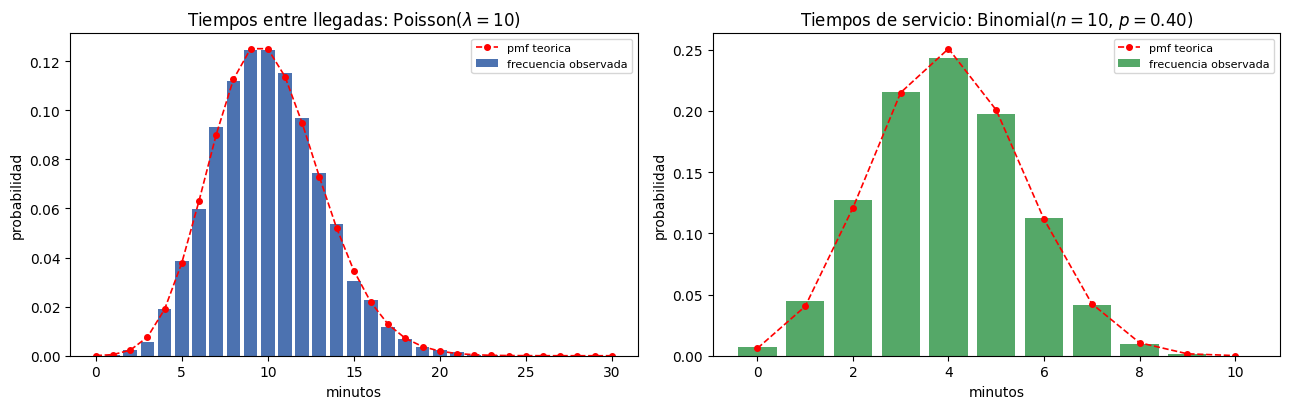

Valores de servicio iguales a cero en la muestra de validacion: 73 de 10000 (0.730%)
Tiempos entre llegadas iguales a cero: 0 de 10000


In [30]:
# --------- Validacion de los dos generadores con 10 000 valores ---------
N_VAL = 10_000
gval = GLC(2391)
pois = np.array([genera_poisson(gval.rand(), LAM) for _ in range(N_VAL)])
gval.reset(160005002)
bino = np.array([genera_binomial(gval.rand(), NBIN, PBIN) for _ in range(N_VAL)])

print("Poisson(10)          media = %.4f (teorica 10)      varianza = %.4f (teorica 10)"
      % (pois.mean(), pois.var(ddof=1)))
print("Binomial(10, 0.40)   media = %.4f (teorica 4)       varianza = %.4f (teorica 2.4)"
      % (bino.mean(), bino.var(ddof=1)))


def chi2_ajuste(x, pmf_teo, valores, nombre):
    n = len(x)
    obs = np.array([np.sum(x == v) for v in valores], dtype=float)
    esp = n*np.asarray(pmf_teo, dtype=float)
    # se agrupan las clases con frecuencia esperada menor que 5 (regla habitual)
    obs_g, esp_g = [], []
    acc_o = acc_e = 0.0
    for o, e in zip(obs, esp):
        acc_o += o
        acc_e += e
        if acc_e >= 5:
            obs_g.append(acc_o)
            esp_g.append(acc_e)
            acc_o = acc_e = 0.0
    if acc_e > 0:
        obs_g[-1] += acc_o
        esp_g[-1] += acc_e
    obs_g, esp_g = np.array(obs_g), np.array(esp_g)
    chi2 = float(np.sum((obs_g - esp_g)**2/esp_g))
    gl = len(obs_g) - 1
    crit = float(stats.chi2.ppf(0.95, gl))
    print("%s:  chi2 = %.4f   gl = %d   critico = %.4f   ->  %s"
          % (nombre, chi2, gl, crit, "ajusta" if chi2 <= crit else "no ajusta"))
    return chi2, gl, crit


v_p = np.arange(0, 31)
chi2_ajuste(pois, stats.poisson.pmf(v_p, LAM), v_p, "Poisson(10)")
v_b = np.arange(0, NBIN + 1)
chi2_ajuste(bino, stats.binom.pmf(v_b, NBIN, PBIN), v_b, "Binomial(10, 0.40)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
vals, cnt = np.unique(pois, return_counts=True)
ax1.bar(vals, cnt/N_VAL, width=0.8, color="#4C72B0", label="frecuencia observada")
ax1.plot(v_p, stats.poisson.pmf(v_p, LAM), "o--", color="red", ms=4, lw=1.2, label="pmf teorica")
ax1.set_title("Tiempos entre llegadas: Poisson($\\lambda = 10$)")
ax1.set_xlabel("minutos"); ax1.set_ylabel("probabilidad"); ax1.legend(fontsize=8)

vals, cnt = np.unique(bino, return_counts=True)
ax2.bar(vals, cnt/N_VAL, width=0.8, color="#55A868", label="frecuencia observada")
ax2.plot(v_b, stats.binom.pmf(v_b, NBIN, PBIN), "o--", color="red", ms=4, lw=1.2, label="pmf teorica")
ax2.set_title("Tiempos de servicio: Binomial($n = 10$, $p = 0.40$)")
ax2.set_xlabel("minutos"); ax2.set_ylabel("probabilidad"); ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

print("Valores de servicio iguales a cero en la muestra de validacion: %d de %d (%.3f%%)"
      % (int(np.sum(bino == 0)), N_VAL, 100*np.mean(bino == 0)))
print("Tiempos entre llegadas iguales a cero: %d de %d" % (int(np.sum(pois == 0)), N_VAL))


### Sección 5.1 del Laboratorio 1: la tabla de la simulación

Se generan los 20 tiempos entre llegadas con el generador Poisson y los 20 tiempos de servicio con el
Binomial, usando una semilla distinta para cada uno. Esto es el equivalente de la nota de la guía del
Laboratorio 1, que pedía un dado o una ruleta independiente para cada variable aleatoria.


In [31]:
# ---------------------------------------------------------------------------
# Simulacion ad hoc del Laboratorio 1 (secciones 5.1 y 5.2) con las nuevas
# variables aleatorias. Reglas identicas a la Tabla 1.1 de [Banks1998]:
#   (3) llegada_i  = llegada_{i-1} + tba_i,  llegada_1 = 0
#   (5) inicio_i   = max(llegada_i, fin_{i-1})
#   (6) fin_i      = inicio_i + servicio_i
#   (7) sistema_i  = fin_i - llegada_i
#   (8) ocioso_i   = max(0, llegada_i - fin_{i-1}),  ocioso_1 = 0
#   (9) cola_i     = inicio_i - llegada_i
# ---------------------------------------------------------------------------
COLS = ["(1) Cliente", "(2) Tiempo entre llegadas", "(3) Tiempo de llegada",
        "(4) Tiempo de servicio", "(5) Inicio del servicio", "(6) Fin del servicio",
        "(7) Tiempo en el sistema", "(8) Tiempo ocioso", "(9) Tiempo en cola"]


def simular(tba, serv):
    n = len(serv)
    tba = list(tba)
    tba[0] = 0                               # el cliente 1 llega en el instante 0
    lleg = [0]*n; ini = [0]*n; fin = [0]*n
    sis = [0]*n; oci = [0]*n; col = [0]*n
    lleg[0], ini[0] = 0, 0
    fin[0] = serv[0]
    sis[0] = fin[0] - lleg[0]
    for i in range(1, n):
        lleg[i] = lleg[i-1] + tba[i]
        ini[i] = max(lleg[i], fin[i-1])
        fin[i] = ini[i] + serv[i]
        sis[i] = fin[i] - lleg[i]
        oci[i] = max(0, lleg[i] - fin[i-1])
        col[i] = ini[i] - lleg[i]
    return pd.DataFrame({COLS[0]: np.arange(1, n + 1), COLS[1]: tba, COLS[2]: lleg,
                         COLS[3]: serv, COLS[4]: ini, COLS[5]: fin, COLS[6]: sis,
                         COLS[7]: oci, COLS[8]: col})


def medidas(tabla):
    n = len(tabla)
    total = int(tabla[COLS[5]].iloc[-1])            # tiempo total de la simulacion
    suma_sis = int(tabla[COLS[6]].sum())
    suma_oci = int(tabla[COLS[7]].sum())
    suma_col = int(tabla[COLS[8]].sum())
    n_esp = int((tabla[COLS[8]] > 0).sum())
    return {
        "Tiempo promedio en el sistema": suma_sis/n,
        "Porcentaje de tiempo ocioso": suma_oci/total,
        "Tiempo de espera promedio por cliente": suma_col/n,
        "Fraccion de clientes que espero": n_esp/n,
        "Tiempo de espera promedio de quienes esperaron": (suma_col/n_esp) if n_esp else 0.0,
        "_n": n, "_total": total, "_sum_sis": suma_sis, "_sum_oci": suma_oci,
        "_sum_col": suma_col, "_n_esp": n_esp,
    }


N_CLIENTES = 20
gen_lleg = GLC(2391)          # una semilla por variable, como los dos dados del Lab 1
gen_serv = GLC(160005002)

tba20 = [genera_poisson(gen_lleg.rand(), LAM) for _ in range(N_CLIENTES)]
srv20 = [genera_binomial(gen_serv.rand(), NBIN, PBIN) for _ in range(N_CLIENTES)]

tabla20 = simular(tba20, srv20)
tabla20_muestra = tabla20.copy()
tabla20_muestra.loc[0, COLS[1]] = np.nan       # el cliente 1 no tiene tiempo entre llegadas
display(tabla20_muestra)

sumas = tabla20[[COLS[6], COLS[7], COLS[8]]].sum()
print("Sumas de control  ->  (7) = %d min    (8) = %d min    (9) = %d min"
      % (sumas.iloc[0], sumas.iloc[1], sumas.iloc[2]))
print("Tiempo total de la simulacion: %d min" % int(tabla20[COLS[5]].iloc[-1]))


,(1) Cliente,(2) Tiempo entre llegadas,(3) Tiempo de llegada,(4) Tiempo de servicio,(5) Inicio del servicio,(6) Fin del servicio,(7) Tiempo en el sistema,(8) Tiempo ocioso,(9) Tiempo en cola
0,1,NaN,0,4,0,4,4,0,0
1,2,12.0,12,4,12,16,4,8,0
2,3,11.0,23,4,23,27,4,7,0
3,4,12.0,35,2,35,37,2,8,0
4,5,12.0,47,3,47,50,3,10,0
5,6,9.0,56,3,56,59,3,6,0
6,7,11.0,67,7,67,74,7,8,0
7,8,14.0,81,2,81,83,2,7,0
8,9,9.0,90,1,90,91,1,7,0
9,10,12.0,102,5,102,107,5,11,0


Sumas de control  ->  (7) = 71 min    (8) = 114 min    (9) = 1 min
Tiempo total de la simulacion: 184 min


### Sección 5.2 del Laboratorio 1: las cinco medidas de desempeño


In [32]:
# --------- Seccion 5.2 del Laboratorio 1: las cinco medidas de desempeno ---------
m20 = medidas(tabla20)

detalle = pd.DataFrame([
    ["Tiempo promedio en el sistema", "suma(7) / N = %d/%d" % (m20["_sum_sis"], m20["_n"]),
     round(m20["Tiempo promedio en el sistema"], 4), "min"],
    ["Porcentaje de tiempo ocioso", "suma(8) / T = %d/%d" % (m20["_sum_oci"], m20["_total"]),
     round(m20["Porcentaje de tiempo ocioso"], 4), "proporcion"],
    ["Tiempo de espera promedio por cliente", "suma(9) / N = %d/%d" % (m20["_sum_col"], m20["_n"]),
     round(m20["Tiempo de espera promedio por cliente"], 4), "min"],
    ["Fraccion de clientes que espero", "Ne / N = %d/%d" % (m20["_n_esp"], m20["_n"]),
     round(m20["Fraccion de clientes que espero"], 4), "proporcion"],
    ["Tiempo de espera promedio de quienes esperaron",
     "suma(9) / Ne = %d/%d" % (m20["_sum_col"], m20["_n_esp"]) if m20["_n_esp"] else "sin datos",
     round(m20["Tiempo de espera promedio de quienes esperaron"], 4), "min"],
], columns=["Medida de desempeno", "Calculo", "Valor", "Unidad"])
display(detalle)

rho = (NBIN*PBIN)/LAM
print("Intensidad de trafico teorica:  rho = E[S]/E[A] = %.1f/%.1f = %.4f" % (NBIN*PBIN, LAM, rho))
print("Porcentaje de tiempo ocioso teorico a largo plazo:  1 - rho = %.4f" % (1 - rho))
print("Porcentaje de tiempo ocioso observado en esta corrida: %.4f"
      % m20["Porcentaje de tiempo ocioso"])


,Medida de desempeno,Calculo,Valor,Unidad
0,Tiempo promedio en el sistema,suma(7) / N = 71/20,3.5500,min
1,Porcentaje de tiempo ocioso,suma(8) / T = 114/184,0.6196,proporcion
2,Tiempo de espera promedio por cliente,suma(9) / N = 1/20,0.0500,min
3,Fraccion de clientes que espero,Ne / N = 1/20,0.0500,proporcion
4,Tiempo de espera promedio de quienes esperaron,suma(9) / Ne = 1/1,1.0000,min


Intensidad de trafico teorica:  rho = E[S]/E[A] = 4.0/10.0 = 0.4000
Porcentaje de tiempo ocioso teorico a largo plazo:  1 - rho = 0.6000
Porcentaje de tiempo ocioso observado en esta corrida: 0.6196


### Comparación con el Laboratorio 1

Para comparar en igualdad de condiciones vuelvo a correr el modelo del Laboratorio 1, con las
uniformes discretas $U\{1,10\}$ y $U\{1,6\}$, pero alimentado por el mismo generador congruencial y
con las mismas semillas. Así lo único que cambia entre los dos modelos son las distribuciones, no la
fuente de aleatoriedad.


In [33]:
# ---------------------------------------------------------------------------
# Comparacion con el Laboratorio 1. Para que la comparacion sea justa se vuelve
# a correr el modelo del Lab 1 (uniforme discreta U{1,10} y U{1,6}) con el MISMO
# generador congruencial y las MISMAS semillas, cambiando solo las distribuciones.
# ---------------------------------------------------------------------------
def uniforme_discreta(u, k):
    return int(k*u) + 1            # X = Ent(k*U) + 1


def corrida(modelo, n_clientes, s_lleg, s_serv):
    ga, gs = GLC(s_lleg), GLC(s_serv)
    if modelo == "lab1":
        tba = [uniforme_discreta(ga.rand(), 10) for _ in range(n_clientes)]
        srv = [uniforme_discreta(gs.rand(), 6) for _ in range(n_clientes)]
    else:
        tba = [genera_poisson(ga.rand(), LAM) for _ in range(n_clientes)]
        srv = [genera_binomial(gs.rand(), NBIN, PBIN) for _ in range(n_clientes)]
    return simular(tba, srv)


tabla20_lab1 = corrida("lab1", N_CLIENTES, 2391, 160005002)
m20_lab1 = medidas(tabla20_lab1)

MEDIDAS = ["Tiempo promedio en el sistema", "Porcentaje de tiempo ocioso",
           "Tiempo de espera promedio por cliente", "Fraccion de clientes que espero",
           "Tiempo de espera promedio de quienes esperaron"]

comp = pd.DataFrame({
    "Medida": MEDIDAS,
    "Lab 1  U{1,10} y U{1,6}": [round(m20_lab1[k], 4) for k in MEDIDAS],
    "Lab 2  Poisson(10) y Bin(10, 0.4)": [round(m20[k], 4) for k in MEDIDAS],
})
comp["Diferencia"] = (comp.iloc[:, 2] - comp.iloc[:, 1]).round(4)
print("Una corrida de 20 clientes con cada modelo (mismas semillas)")
display(comp)

par = pd.DataFrame({
    "Parametro": ["E[tiempo entre llegadas]", "Desv. est. entre llegadas",
                  "E[tiempo de servicio]", "Desv. est. del servicio",
                  "Intensidad de trafico rho", "Tiempo ocioso teorico 1 - rho",
                  "Coef. de variacion de las llegadas", "Coef. de variacion del servicio"],
    "Lab 1": [5.5, round(np.sqrt((10**2 - 1)/12), 4), 3.5, round(np.sqrt((6**2 - 1)/12), 4),
              round(3.5/5.5, 4), round(1 - 3.5/5.5, 4),
              round(np.sqrt((10**2 - 1)/12)/5.5, 4), round(np.sqrt((6**2 - 1)/12)/3.5, 4)],
    "Lab 2": [float(LAM), round(np.sqrt(LAM), 4), NBIN*PBIN, round(np.sqrt(NBIN*PBIN*(1 - PBIN)), 4),
              round(rho, 4), round(1 - rho, 4),
              round(np.sqrt(LAM)/LAM, 4), round(np.sqrt(NBIN*PBIN*(1 - PBIN))/(NBIN*PBIN), 4)],
})
print("Parametros teoricos de los dos modelos")
display(par)


Una corrida de 20 clientes con cada modelo (mismas semillas)


,Medida,"Lab 1 U{1,10} y U{1,6}","Lab 2 Poisson(10) y Bin(10, 0.4)",Diferencia
0,Tiempo promedio en el sistema,3.4500,3.5500,0.1000
1,Porcentaje de tiempo ocioso,0.4608,0.6196,0.1588
2,Tiempo de espera promedio por cliente,0.7000,0.0500,-0.6500
3,Fraccion de clientes que espero,0.3500,0.0500,-0.3000
4,Tiempo de espera promedio de quienes esperaron,2.0000,1.0000,-1.0000


Parametros teoricos de los dos modelos


,Parametro,Lab 1,Lab 2
0,E[tiempo entre llegadas],5.5000,10.0000
1,Desv. est. entre llegadas,2.8723,3.1623
2,E[tiempo de servicio],3.5000,4.0000
3,Desv. est. del servicio,1.7078,1.5492
4,Intensidad de trafico rho,0.6364,0.4000
5,Tiempo ocioso teorico 1 - rho,0.3636,0.6000
6,Coef. de variacion de las llegadas,0.5222,0.3162
7,Coef. de variacion del servicio,0.4880,0.3873


#### Diez corridas de cada modelo con 20 clientes


Modelo del Laboratorio 1: U{1,10} y U{1,6}


,Corrida,Tiempo promedio en el sistema,Porcentaje de tiempo ocioso,Tiempo de espera promedio por cliente,Fraccion de clientes que espero,Tiempo de espera promedio de quienes esperaron
0,1,3.4500,0.4608,0.7000,0.3500,2.0000
1,2,4.3500,0.4144,1.1000,0.3500,3.1429
2,3,3.6500,0.4087,0.2500,0.1500,1.6667
3,4,4.0000,0.3725,0.8000,0.3500,2.2857
4,5,3.7500,0.4486,0.8000,0.2000,4.0000
5,6,3.7500,0.4333,0.3500,0.1500,2.3333
6,7,4.1500,0.3214,0.3500,0.2000,1.7500
7,8,2.5000,0.5586,0.0500,0.0500,1.0000
8,9,3.5500,0.4844,0.2500,0.1000,2.5000
9,10,3.8500,0.3600,0.6500,0.3500,1.8571


Modelo del Laboratorio 2: Poisson(10) y Binomial(10, 0.40)


,Corrida,Tiempo promedio en el sistema,Porcentaje de tiempo ocioso,Tiempo de espera promedio por cliente,Fraccion de clientes que espero,Tiempo de espera promedio de quienes esperaron
0,1,3.5500,0.6196,0.0500,0.0500,1.0000
1,2,3.9000,0.5979,0.0000,0.0000,0.0000
2,3,3.8500,0.6188,0.0000,0.0000,0.0000
3,4,3.6500,0.6117,0.0000,0.0000,0.0000
4,5,3.5500,0.6450,0.0000,0.0000,0.0000
5,6,3.9000,0.6139,0.0000,0.0000,0.0000
6,7,4.2500,0.5707,0.0000,0.0000,0.0000
7,8,3.0500,0.6839,0.0000,0.0000,0.0000
8,9,3.8500,0.6316,0.0000,0.0000,0.0000
9,10,3.7500,0.6011,0.0000,0.0000,0.0000


Promedio de las 10 corridas de cada modelo


,Medida,Lab 1 media,Lab 1 S,Lab 2 media,Lab 2 S,Cambio %
0,Tiempo promedio en el sistema,3.7000,0.5022,3.7300,0.3146,0.8
1,Porcentaje de tiempo ocioso,0.4263,0.0678,0.6194,0.0302,45.3
2,Tiempo de espera promedio por cliente,0.5300,0.3276,0.0050,0.0158,-99.1
3,Fraccion de clientes que espero,0.2250,0.1161,0.0050,0.0158,-97.8
4,Tiempo de espera promedio de quienes esperaron,2.2536,0.8367,0.1000,0.3162,-95.6


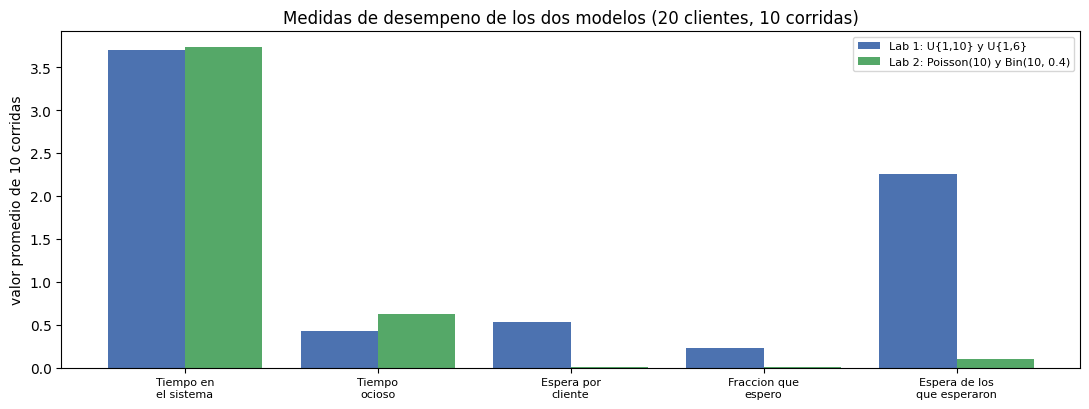

In [34]:
# --------- Diez corridas de cada modelo, para no juzgar por una sola ---------
N_CORRIDAS = 10
res_lab1, res_lab2 = [], []
for r in range(N_CORRIDAS):
    s1, s2 = 2391 + 7919*r, 160005002 + 7919*r      # semillas separadas por un primo
    res_lab1.append(medidas(corrida("lab1", N_CLIENTES, s1, s2)))
    res_lab2.append(medidas(corrida("lab2", N_CLIENTES, s1, s2)))


def resumen(res, etiqueta):
    d = {"Corrida": list(range(1, N_CORRIDAS + 1))}
    for k in MEDIDAS:
        d[k] = [round(r[k], 4) for r in res]
    df = pd.DataFrame(d)
    fila_m = {"Corrida": "Media"}
    fila_s = {"Corrida": "Desv. est."}
    for k in MEDIDAS:
        fila_m[k] = round(float(np.mean([r[k] for r in res])), 4)
        fila_s[k] = round(float(np.std([r[k] for r in res], ddof=1)), 4)
    df = pd.concat([df, pd.DataFrame([fila_m, fila_s])], ignore_index=True)
    print(etiqueta)
    display(df)
    return df


df_lab1 = resumen(res_lab1, "Modelo del Laboratorio 1: U{1,10} y U{1,6}")
df_lab2 = resumen(res_lab2, "Modelo del Laboratorio 2: Poisson(10) y Binomial(10, 0.40)")

med_l1 = {k: float(np.mean([r[k] for r in res_lab1])) for k in MEDIDAS}
med_l2 = {k: float(np.mean([r[k] for r in res_lab2])) for k in MEDIDAS}
sd_l1 = {k: float(np.std([r[k] for r in res_lab1], ddof=1)) for k in MEDIDAS}
sd_l2 = {k: float(np.std([r[k] for r in res_lab2], ddof=1)) for k in MEDIDAS}

final = pd.DataFrame({
    "Medida": MEDIDAS,
    "Lab 1 media": [round(med_l1[k], 4) for k in MEDIDAS],
    "Lab 1 S": [round(sd_l1[k], 4) for k in MEDIDAS],
    "Lab 2 media": [round(med_l2[k], 4) for k in MEDIDAS],
    "Lab 2 S": [round(sd_l2[k], 4) for k in MEDIDAS],
})
final["Cambio %"] = [round(100*(med_l2[k] - med_l1[k])/med_l1[k], 1) if med_l1[k] else np.nan
                     for k in MEDIDAS]
print("Promedio de las 10 corridas de cada modelo")
display(final)

fig, ax = plt.subplots(figsize=(11, 4.2))
x = np.arange(len(MEDIDAS))
ax.bar(x - 0.2, [med_l1[k] for k in MEDIDAS], 0.4, label="Lab 1: U{1,10} y U{1,6}", color="#4C72B0")
ax.bar(x + 0.2, [med_l2[k] for k in MEDIDAS], 0.4, label="Lab 2: Poisson(10) y Bin(10, 0.4)", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(["Tiempo en\nel sistema", "Tiempo\nocioso", "Espera por\ncliente",
                    "Fraccion que\nespero", "Espera de los\nque esperaron"], fontsize=8)
ax.set_ylabel("valor promedio de 10 corridas")
ax.set_title("Medidas de desempeno de los dos modelos (20 clientes, 10 corridas)")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


#### Diez corridas de cada modelo con 200 clientes


In [35]:
# ---------------------------------------------------------------------------
# Con 20 clientes la cola casi nunca se forma bajo el modelo del Lab 2, asi que
# la medida "espera de quienes esperaron" queda sin definir en la mayoria de las
# corridas. Se repiten las 10 corridas con 200 clientes para poder medirla.
# ---------------------------------------------------------------------------
N_LARGO = 200
res_l1_200, res_l2_200 = [], []
for r in range(N_CORRIDAS):
    s1, s2 = 2391 + 7919*r, 160005002 + 7919*r
    res_l1_200.append(medidas(corrida("lab1", N_LARGO, s1, s2)))
    res_l2_200.append(medidas(corrida("lab2", N_LARGO, s1, s2)))

m1 = {k: float(np.mean([r[k] for r in res_l1_200])) for k in MEDIDAS}
m2 = {k: float(np.mean([r[k] for r in res_l2_200])) for k in MEDIDAS}
s1_ = {k: float(np.std([r[k] for r in res_l1_200], ddof=1)) for k in MEDIDAS}
s2_ = {k: float(np.std([r[k] for r in res_l2_200], ddof=1)) for k in MEDIDAS}

tabla200 = pd.DataFrame({
    "Medida": MEDIDAS,
    "Lab 1 media": [round(m1[k], 4) for k in MEDIDAS],
    "Lab 1 S": [round(s1_[k], 4) for k in MEDIDAS],
    "Lab 2 media": [round(m2[k], 4) for k in MEDIDAS],
    "Lab 2 S": [round(s2_[k], 4) for k in MEDIDAS],
})
tabla200["Cambio %"] = [round(100*(m2[k] - m1[k])/m1[k], 1) if m1[k] else np.nan for k in MEDIDAS]
print("Promedio de 10 corridas de %d clientes con cada modelo" % N_LARGO)
display(tabla200)

corridas_con_cola_l2 = int(np.sum([r["Fraccion de clientes que espero"] > 0 for r in res_l2_200]))
print("Corridas de 200 clientes en las que se formo cola al menos una vez:")
print("  modelo del Lab 1: %d de %d" % (
    int(np.sum([r["Fraccion de clientes que espero"] > 0 for r in res_l1_200])), N_CORRIDAS))
print("  modelo del Lab 2: %d de %d" % (corridas_con_cola_l2, N_CORRIDAS))
print("Tiempo ocioso teorico 1 - rho  ->  Lab 1: %.4f    Lab 2: %.4f" % (1 - 3.5/5.5, 1 - rho))
print("Tiempo ocioso medido           ->  Lab 1: %.4f    Lab 2: %.4f"
      % (m1["Porcentaje de tiempo ocioso"], m2["Porcentaje de tiempo ocioso"]))


Promedio de 10 corridas de 200 clientes con cada modelo

,Medida,Lab 1 media,Lab 1 S,Lab 2 media,Lab 2 S,Cambio %
0,Tiempo promedio en el sistema,4.6470,0.5301,3.9980,0.1690,-14.0
1,Porcentaje de tiempo ocioso,0.3745,0.0443,0.6034,0.0191,61.1
2,Tiempo de espera promedio por cliente,1.1890,0.3684,0.0385,0.0253,-96.8
3,Fraccion de clientes que espero,0.3505,0.0600,0.0225,0.0106,-93.6
4,Tiempo de espera promedio de quienes esperaron,3.3477,0.5540,1.5500,0.4529,-53.7


Corridas de 200 clientes en las que se formo cola al menos una vez:
  modelo del Lab 1: 10 de 10
  modelo del Lab 2: 10 de 10
Tiempo ocioso teorico 1 - rho  ->  Lab 1: 0.3636    Lab 2: 0.6000
Tiempo ocioso medido           ->  Lab 1: 0.3745    Lab 2: 0.6034


### Respuestas a las preguntas del punto 5.4

#### ¿Qué puede decir de los resultados obtenidos?

Lo primero que salta a la vista en la corrida de 20 clientes es que la cola prácticamente desapareció.
De los 20 clientes solo uno esperó, y esperó 1 minuto: el cliente 12, que llegó en el minuto 114
cuando el cajero todavía estaba atendiendo al cliente 11 hasta el minuto 115. La suma de la columna
(9) es de 1 minuto para toda la simulación. En cambio la columna (8) suma 114 minutos de tiempo
ocioso sobre un total de 184, o sea que el cajero estuvo desocupado el 61.96 % del tiempo.

Ese 61.96 % no es casualidad. La intensidad de tráfico del sistema es
$\rho = E[S]/E[A] = 4/10 = 0.40$, y la teoría dice que a largo plazo la proporción de tiempo ocioso
tiende a $1 - \rho = 0.60$. Con apenas 20 clientes ya se está a menos de dos puntos porcentuales. Me
parece la mejor validación de que la simulación y los dos generadores están bien: el resultado cae
donde la teoría dice que tiene que caer, y ese valor no se programó en ninguna parte, sale solo de
sortear 40 números.

Los dos generadores también quedaron validados por separado. Con 10 000 valores, la Poisson dio media
10.017 y varianza 9.881, contra 10 y 10 teóricos, con $\chi^2 = 23.07$ frente al crítico 31.41. La
Binomial dio media 3.962 y varianza 2.455, contra 4 y 2.4, con $\chi^2 = 15.04$ frente al crítico
16.92. Las dos ajustan.

Aparece además una situación que en el Laboratorio 1 no podía darse: la Binomial puede
devolver 0. En la muestra de validación salieron 73 servicios de duración cero en 10 000, un 0.73 %,
que corresponde exactamente a $0.6^{10} = 0.006047$ más la variabilidad del muestreo. Un tiempo de
servicio de cero minutos no tiene mucho sentido físico para un cajero de banco, y con las uniformes
del Laboratorio 1 no podía pasar porque el mínimo era 1. Lo mismo aplica a la Poisson, que
podría dar tiempos entre llegadas de 0, aunque con $\lambda = 10$ eso ocurre con probabilidad
$e^{-10} = 0.0000454$ y en 10 000 valores no apareció ninguno.

#### ¿Qué similitudes o diferencias se presentan frente al Laboratorio 1?

**Lo que se parece.** La estructura del modelo es la misma: un servidor, disciplina FIFO, las mismas
nueve columnas y las mismas cinco medidas. El tiempo promedio en el sistema es lo que menos cambia:
3.55 minutos acá contra 3.45 en la corrida equivalente del Laboratorio 1, y promediando 10 corridas
de 200 clientes, 4.00 contra 4.65. Tiene sentido, porque el tiempo en el sistema es servicio más
espera, y como casi nadie espera, esa medida se queda pegada al tiempo de servicio promedio de 4
minutos.

También se parece el método. Sigue siendo simulación *ad hoc*, avanzando cliente por cliente con
aritmética elemental. Lo único que se reemplazó fue de dónde salen los dos números.

**Lo que cambia.** La diferencia de fondo es la congestión. La intensidad de tráfico pasó de
$\rho = 3.5/5.5 = 0.636$ a $\rho = 4/10 = 0.400$. Con 10 corridas de 200 clientes cada una:

| Medida | Lab 1 | Lab 2 | Cambio |
|---|---|---|---|
| Tiempo promedio en el sistema | 4.6470 | 3.9980 | −14.0 % |
| Porcentaje de tiempo ocioso | 0.3745 | 0.6034 | +61.1 % |
| Espera promedio por cliente | 1.1890 | 0.0385 | −96.8 % |
| Fracción que esperó | 0.3505 | 0.0225 | −93.6 % |
| Espera de quienes esperaron | 3.3477 | 1.5500 | −53.7 % |

El tiempo ocioso medido, 0.3745 y 0.6034, reproduce casi exactamente los valores teóricos de
$1-\rho$, que son 0.3636 y 0.6000. Y la fracción de clientes que espera se derrumbó de uno de cada
tres a uno de cada cuarenta y cinco.

**Un problema práctico que apareció.** Con solo 20 clientes el modelo del Laboratorio 2 es tan poco
congestionado que en 9 de las 10 corridas no esperó absolutamente nadie. Eso deja sin definir la
medida "espera promedio de quienes esperaron", porque el denominador $N_e$ vale cero. Por eso repetí
las 10 corridas con 200 clientes, y ahí sí se formó cola en las 10. Es un recordatorio de que el
tamaño de la corrida hay que elegirlo pensando en el evento que se quiere medir, no solo en el
promedio general.

**Sobre la variabilidad.** Las desviaciones estándar entre corridas también bajaron. Para el tiempo
promedio en el sistema con 200 clientes, $S$ pasó de 0.5301 a 0.1690, es decir que las corridas del
modelo nuevo se parecen mucho más entre sí. La razón está en los coeficientes de variación: los de la
Poisson y la Binomial son 0.316 y 0.387, contra 0.522 y 0.488 de las uniformes discretas. Las
distribuciones nuevas son relativamente menos dispersas alrededor de su media, y en un sistema de
colas la variabilidad es tan importante como el promedio para que se formen filas.

**Una precaución sobre la comparación.** Los dos modelos no se diferencian solo en la forma de la
distribución, también en la media. Si la comparación fuera solo de forma habría que ajustar las
medias para dejar $\rho$ igual en los dos casos. Como la guía fija $\lambda = 10$, $n = 10$ y
$p = 0.40$, la diferencia de congestión viene incluida en el enunciado, y buena parte de lo que se
observa se explica por ahí y no por el cambio de familia de distribuciones.

Como comprobación adicional, el modelo del Laboratorio 1 vuelto a correr acá con el generador
congruencial dio, sobre 200 clientes, 4.647 minutos en el sistema, 37.45 % de tiempo ocioso y 0.3505
de fracción que esperó. Los valores que reporté en el informe del Laboratorio 1, generados en su
momento con otro generador, fueron 4.60, 36.07 % y 0.3545. Que dos fuentes de aleatoriedad distintas
den prácticamente lo mismo confirma que el motor de simulación es correcto.


---

## 7. Bibliografía

[Ross99] Ross, Sheldon. *Simulación*, 2.ª edición. Pearson Press, 1999. Capítulos 3 y 4.

[Banks1998] Banks, Jerry. *Handbook of Simulation: Principles, Methodology, Advances, Applications,
and Practice*. John Wiley & Sons, Inc., 1998. Capítulo 1.

[Mancilla2000] Mancilla Herrera, Alfonso Manuel. *Números aleatorios. Historia, teoría y
aplicaciones*. Ingeniería y Desarrollo, núm. 8, diciembre de 2000, pp. 49-69. Universidad del Norte,
Barranquilla, Colombia.
